# Curriculum x Reg Ablation 对比

对比 4 种组合:
1. **baseline** - Curriculum OFF, Reg OFF
2. **curriculum_only** - Curriculum ON, Reg OFF
3. **reg_only** - Curriculum OFF, Reg ON
4. **curriculum_reg** - Curriculum ON, Reg ON

In [55]:
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt

In [56]:
# ============================================================================
# 配置区
# ============================================================================

# 新项目的实验文件路径
new_ablation_dir = '/home/sunj11/Documents/curriculum_sparse_reg/results'

# 旧项目的实验文件路径
old_ablation_dir = '/home/sunj11/Documents/diffusion/curriculum_sparse_ablation/results'

# 新项目实验 (4种组合)
new_experiments = {
    'baseline': f'{new_ablation_dir}/results_baseline.pkl',
    'curriculum_only': f'{new_ablation_dir}/results_curriculum_only.pkl',
    'reg_only': f'{new_ablation_dir}/results_reg_only.pkl',
    'curriculum_reg': f'{new_ablation_dir}/results_curriculum_reg.pkl',
}

# 旧项目实验（用于对比）
old_experiments = {
    'sparsity_only': f'{old_ablation_dir}/results_sparsity_only.pkl',
    'curriculum_sparsity': f'{old_ablation_dir}/results_curriculum_sparsity.pkl',
}

# 通用配置
show_bias = True
top_n = 10
figsize_single = (18, 22)

In [57]:
# ============================================================================
# 核心函数
# ============================================================================

def load_results(path):
    """加载pickle文件，处理模块兼容性问题"""
    import sys
    
    # 添加旧项目路径以支持 sparse_model 导入
    old_project_path = '/home/sunj11/Documents/diffusion/curriculum_sparse_ablation'
    if old_project_path not in sys.path:
        sys.path.insert(0, old_project_path)
    
    try:
        with open(path, 'rb') as f:
            return pickle.load(f)
    except ModuleNotFoundError as e:
        if 'sparse_model' in str(e):
            # 如果找不到 sparse_model，尝试从旧项目目录加载
            print(f"Warning: {e}")
            print(f"  尝试从旧项目目录加载...")
            with open(path, 'rb') as f:
                return pickle.load(f)
        else:
            raise

def extract_top_neuron_data(results, rank_by, plot_primary, plot_secondary, show_bias, plot_tertiary=None):
    """提取Top神经元的数据 (优化版)"""
    result = results[0]
    similarities_history = result.get('training_history', {}).get('similarities', [])
    
    if not similarities_history:
        print("Error: No training history found.")
        return None
    
    # 获取基本信息
    first_entry = similarities_history[0]
    sim_test = first_entry.get('similarities', {}).get(rank_by)
    if sim_test is None:
        print(f"Error: {rank_by} not found in similarities")
        return None
    
    num_neurons = sim_test.shape[0]
    
    # 预分配数组
    iterations = []
    all_sims_rank = {i: [] for i in range(num_neurons)}
    all_sims_primary = {i: [] for i in range(num_neurons)}
    all_sims_secondary = {i: [] for i in range(num_neurons)}
    all_sims_tertiary = {i: [] for i in range(num_neurons)} if plot_tertiary else {}
    all_bias_values = {i: [] for i in range(num_neurons)} if show_bias else {}
    
    # 一次遍历提取所有数据
    for entry in similarities_history:
        iteration = entry.get('iteration', entry.get('epoch', len(iterations) + 1))
        iterations.append(iteration)
        
        # 提取 similarities (批量处理)
        sims_dict = entry.get('similarities', {})
        
        for key, storage in [(rank_by, all_sims_rank), 
                            (plot_primary, all_sims_primary), 
                            (plot_secondary, all_sims_secondary)]:
            sim = sims_dict.get(key)
            if sim is not None:
                sim_np = sim.cpu().numpy()
                for i in range(num_neurons):
                    storage[i].append(sim_np[i])
        
        # plot_tertiary
        if plot_tertiary:
            sim = sims_dict.get(plot_tertiary)
            if sim is not None:
                sim_np = sim.cpu().numpy()
                for i in range(num_neurons):
                    all_sims_tertiary[i].append(sim_np[i])
        
        # 提取 bias (保持与 iterations 同步)
        if show_bias:
            b_hidden = entry.get('model_state', {}).get('neurons', {}).get('b_hidden')
            if b_hidden is not None:
                b_hidden_np = b_hidden.cpu().numpy()
                for i in range(num_neurons):
                    all_bias_values[i].append(b_hidden_np[i])
            else:
                # 如果没有 bias 数据，用上一个值或 0 填充
                for i in range(num_neurons):
                    if all_bias_values[i]:
                        all_bias_values[i].append(all_bias_values[i][-1])
                    else:
                        all_bias_values[i].append(0.0)
    
    # 计算最终排名
    final_max_sims_abs = {}
    for i in range(num_neurons):
        if all_sims_rank[i]:
            final_sims = all_sims_rank[i][-1]
            final_max_sims_abs[i] = np.max(np.abs(final_sims))
        else:
            final_max_sims_abs[i] = 0
    
    sorted_neurons = sorted(final_max_sims_abs.items(), key=lambda x: x[1], reverse=True)
    
    return {
        'iterations': iterations,
        'biases': all_bias_values,
        'sims_rank': all_sims_rank,
        'sims_primary': all_sims_primary,
        'sims_secondary': all_sims_secondary,
        'sims_tertiary': all_sims_tertiary,
        'sorted_neurons': sorted_neurons,
        'num_neurons': num_neurons
    }


def plot_comparison(data, rank_by, plot_primary, plot_secondary, show_bias, top_n, figsize, title_prefix='', plot_tertiary=None):
    """绘制Top N神经元的子图"""
    iterations = data['iterations']
    biases = data['biases']
    sims_primary = data['sims_primary']
    sims_secondary = data['sims_secondary']
    sims_tertiary = data.get('sims_tertiary', {})
    sorted_neurons = data['sorted_neurons']
    
    n_rows = (top_n + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=figsize)
    axes = axes.flatten() if top_n > 1 else [axes]
    
    fig.suptitle(f'{title_prefix} | Rank by: {rank_by}', fontsize=14, fontweight='bold', y=1.02)
    
    for i, (neuron_idx, final_abs_sim) in enumerate(sorted_neurons[:top_n]):
        ax = axes[i]
        
        # plot_primary: 蓝色粗线 (max)
        max_sims_primary_signed = []
        for t in range(len(iterations)):
            sims = sims_primary[neuron_idx][t]
            max_idx = np.argmax(np.abs(sims))
            max_sims_primary_signed.append(sims[max_idx])
        
        ax.plot(iterations, max_sims_primary_signed, 
               color='blue', linewidth=2.5, alpha=0.8, 
               label=f'max(<wi, {plot_primary[2:]}j>)', linestyle='-')
        
        # plot_secondary: 红色细线 (各 feature) - M2
        num_features = len(sims_secondary[neuron_idx][0])
        for j in range(num_features):
            feature_curve = [sims_secondary[neuron_idx][t][j] for t in range(len(iterations))]
            if j == 0:
                ax.plot(iterations, feature_curve, 
                       color='red', linewidth=0.8, alpha=0.3, 
                       label=f'<wi, {plot_secondary[2:]}j>', linestyle='-')
            else:
                ax.plot(iterations, feature_curve, 
                       color='red', linewidth=0.8, alpha=0.3, linestyle='-')
        
        # plot_tertiary: 青色细线 (各 feature) - M1
        if plot_tertiary and sims_tertiary and neuron_idx in sims_tertiary and sims_tertiary[neuron_idx]:
            num_features_t = len(sims_tertiary[neuron_idx][0])
            for j in range(num_features_t):
                feature_curve = [sims_tertiary[neuron_idx][t][j] for t in range(len(iterations))]
                if j == 0:
                    ax.plot(iterations, feature_curve, 
                           color='cyan', linewidth=0.8, alpha=0.3, 
                           label=f'<wi, {plot_tertiary[2:]}j>', linestyle='-')
                else:
                    ax.plot(iterations, feature_curve, 
                           color='cyan', linewidth=0.8, alpha=0.3, linestyle='-')
        
        # Bias: 确保长度匹配
        if show_bias and biases and neuron_idx in biases and biases[neuron_idx]:
            bias_values = biases[neuron_idx]
            # 确保 bias 长度与 iterations 匹配
            if len(bias_values) == len(iterations):
                ax.plot(iterations, bias_values, 
                       color='green', linewidth=2.5, alpha=0.9, 
                       label='Bias', linestyle='--')
        
        ax.axhline(y=0, color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
        
        final_bias = biases[neuron_idx][-1] if (show_bias and biases and biases[neuron_idx]) else 0
        title = f'Neuron {neuron_idx} (Rank {i+1})\n'
        title += f'max|{rank_by}|={final_abs_sim:.3f}'
        if show_bias:
            title += f', bias={final_bias:.3f}'
        
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Iteration', fontsize=9)
        ax.set_ylabel('Similarity / Bias', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.legend(fontsize=7, loc='best', framealpha=0.9)
        
        y_min, y_max = ax.get_ylim()
        y_range = max(abs(y_min), abs(y_max))
        ax.set_ylim(-y_range * 1.1, y_range * 1.1)
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    return fig, axes


def print_ranking_table(data, rank_by, top_n, show_bias, name=''):
    """打印排名表格"""
    sorted_neurons = data['sorted_neurons']
    biases = data['biases']
    sims_rank = data['sims_rank']
    
    print(f"\n{'='*60}")
    print(f"{name} | Top {top_n} by max|{rank_by}|")
    print(f"{'='*60}")
    
    for rank, (neuron_idx, sim_val_abs) in enumerate(sorted_neurons[:top_n], 1):
        final_sims = sims_rank[neuron_idx][-1]
        max_idx = np.argmax(np.abs(final_sims))
        signed_max = final_sims[max_idx]
        sign = '+' if signed_max >= 0 else '-'
        
        if show_bias and biases and biases[neuron_idx]:
            bias_val = biases[neuron_idx][-1]
            print(f"Rank {rank:2d}: Neuron {neuron_idx:3d} | sim={sim_val_abs:.4f} ({sign}) | bias={bias_val:.4f}")
        else:
            print(f"Rank {rank:2d}: Neuron {neuron_idx:3d} | sim={sim_val_abs:.4f} ({sign})")
    print()

In [58]:
# ============================================================================
# 加载所有实验数据：新项目 + 旧项目
# ============================================================================

print("Loading experiment data...")
all_results = {}
old_results = {}
has_sparsity_comparison = False

# 加载新项目实验
print("\n[NEW PROJECT] Group L1 Regularization:")
for name, path in new_experiments.items():
    try:
        all_results[name] = load_results(path)
        print(f"  ✓ {name}")
    except FileNotFoundError:
        print(f"  ✗ {name} (not found)")

# 加载旧项目实验（用于对比）
print("\n[OLD PROJECT] Hard-Mask Sparsity:")
for name, path in old_experiments.items():
    try:
        result = load_results(path)
        old_results[name] = result
        has_sparsity_comparison = True
        print(f"  ✓ {name}")
    except FileNotFoundError:
        print(f"  ✗ {name} (not found)")

print(f"\nTotal: {len(all_results)} new experiments loaded")
if has_sparsity_comparison:
    print(f"       + {len(old_results)} old experiments for comparison")
print("Done!")

Loading experiment data...

[NEW PROJECT] Group L1 Regularization:
  ✓ baseline
  ✓ curriculum_only
  ✓ reg_only
  ✓ curriculum_reg

[OLD PROJECT] Hard-Mask Sparsity:


  ✓ sparsity_only
  ✓ curriculum_sparsity

Total: 4 new experiments loaded
       + 2 old experiments for comparison
Done!


---
## Summary: 3 实验对比（新项目 vs 旧项目）

In [59]:
# 打印 4+2 个实验的关键指标对比
print("\n" + "="*100)
print("COMPARISON: 4 Ablation Combinations (NEW) + 2 Hard-Mask Sparsity (OLD)")
print("="*100)
print(f"{'Experiment':<25} {'Method':<25} {'W-M1 max':<15} {'W-M2 max':<15} {'Sparsity':<15}")
print("-"*100)

# 4个新项目实验
for name in ['baseline', 'curriculum_only', 'reg_only', 'curriculum_reg']:
    if name not in all_results:
        continue
    result = all_results[name][0]
    metrics = result.get('metrics', {})
    w_m1_max = metrics.get('W_M1_max', 0)
    w_m2_max = metrics.get('W_M2_max', 0)
    
    # 方法描述
    if name == 'baseline':
        method = 'C:OFF, R:OFF'
    elif name == 'curriculum_only':
        method = 'C:ON, R:OFF'
    elif name == 'reg_only':
        method = 'C:OFF, R:ON'
    else:
        method = 'C:ON, R:ON'
    
    # 获取稀疏度信息
    sparsity_history = result.get('training_history', {}).get('sparsity_history', [])
    if sparsity_history:
        final_sparsity = sparsity_history[-1].get('sparsity', 0)
        sparsity_str = f"{final_sparsity:.1%}"
    else:
        sparsity_str = "N/A"
    
    print(f"{name:<25} {method:<25} {w_m1_max:<15.4f} {w_m2_max:<15.4f} {sparsity_str:<15}")

# 旧项目实验（Hard-Mask）
print("-"*100)
for name in ['sparsity_only', 'curriculum_sparsity']:
    if name not in old_results:
        continue
    result = old_results[name][0]
    metrics = result.get('metrics', {})
    w_m1_max = metrics.get('W_M1_max', 0)
    w_m2_max = metrics.get('W_M2_max', 0)
    
    if name == 'sparsity_only':
        method = 'C:OFF, S:ON (OLD)'
    else:
        method = 'C:ON, S:ON (OLD)'
    
    print(f"{name:<25} {method:<25} {w_m1_max:<15.4f} {w_m2_max:<15.4f} {'N/A':<15}")

print("="*100)


COMPARISON: 4 Ablation Combinations (NEW) + 2 Hard-Mask Sparsity (OLD)
Experiment                Method                    W-M1 max        W-M2 max        Sparsity       
----------------------------------------------------------------------------------------------------
baseline                  C:OFF, R:OFF              1.2587          0.2515          N/A            
curriculum_only           C:ON, R:OFF               1.0005          1.2504          N/A            
reg_only                  C:OFF, R:ON               1.1683          0.0927          N/A            
curriculum_reg            C:ON, R:ON                1.1847          0.7274          20.0%          
----------------------------------------------------------------------------------------------------
sparsity_only             C:OFF, S:ON (OLD)         1.0265          0.1880          N/A            
curriculum_sparsity       C:ON, S:ON (OLD)          1.0200          1.0553          N/A            


---
## Rank by W_M2 (同时显示 W_M1)

In [60]:
rank_by = 'W_M2'
plot_primary = 'W_M2'
plot_secondary = 'W_M2'
plot_tertiary = 'W_M1' 

# 提取并打印排名表
all_data_w_m2 = {}
for name, results in all_results.items():
    data = extract_top_neuron_data(results, rank_by, plot_primary, plot_secondary, show_bias, plot_tertiary)
    all_data_w_m2[name] = data
    if data:
        print_ranking_table(data, rank_by, top_n, show_bias, name)


baseline | Top 10 by max|W_M2|
Rank  1: Neuron   3 | sim=0.2510 (+) | bias=0.1432
Rank  2: Neuron  40 | sim=0.2291 (+) | bias=0.1109
Rank  3: Neuron  41 | sim=0.2214 (+) | bias=0.1077
Rank  4: Neuron  79 | sim=0.1305 (+) | bias=0.1623
Rank  5: Neuron  92 | sim=0.1099 (-) | bias=-2.1303
Rank  6: Neuron  67 | sim=0.1091 (+) | bias=-1.0491
Rank  7: Neuron  54 | sim=0.0957 (-) | bias=-1.7510
Rank  8: Neuron  37 | sim=0.0948 (-) | bias=-1.5087
Rank  9: Neuron  66 | sim=0.0894 (-) | bias=-1.6159
Rank 10: Neuron  49 | sim=0.0884 (-) | bias=-2.5491


curriculum_only | Top 10 by max|W_M2|
Rank  1: Neuron  44 | sim=1.2504 (+) | bias=-0.3297
Rank  2: Neuron  20 | sim=1.1856 (+) | bias=0.0520
Rank  3: Neuron  97 | sim=1.1230 (+) | bias=0.0325
Rank  4: Neuron  79 | sim=1.0864 (+) | bias=-0.2125
Rank  5: Neuron  49 | sim=0.8281 (+) | bias=0.0665
Rank  6: Neuron  72 | sim=0.7647 (+) | bias=0.0632
Rank  7: Neuron  85 | sim=0.3856 (+) | bias=-0.9204
Rank  8: Neuron  59 | sim=0.3691 (+) | bias=-1.0306


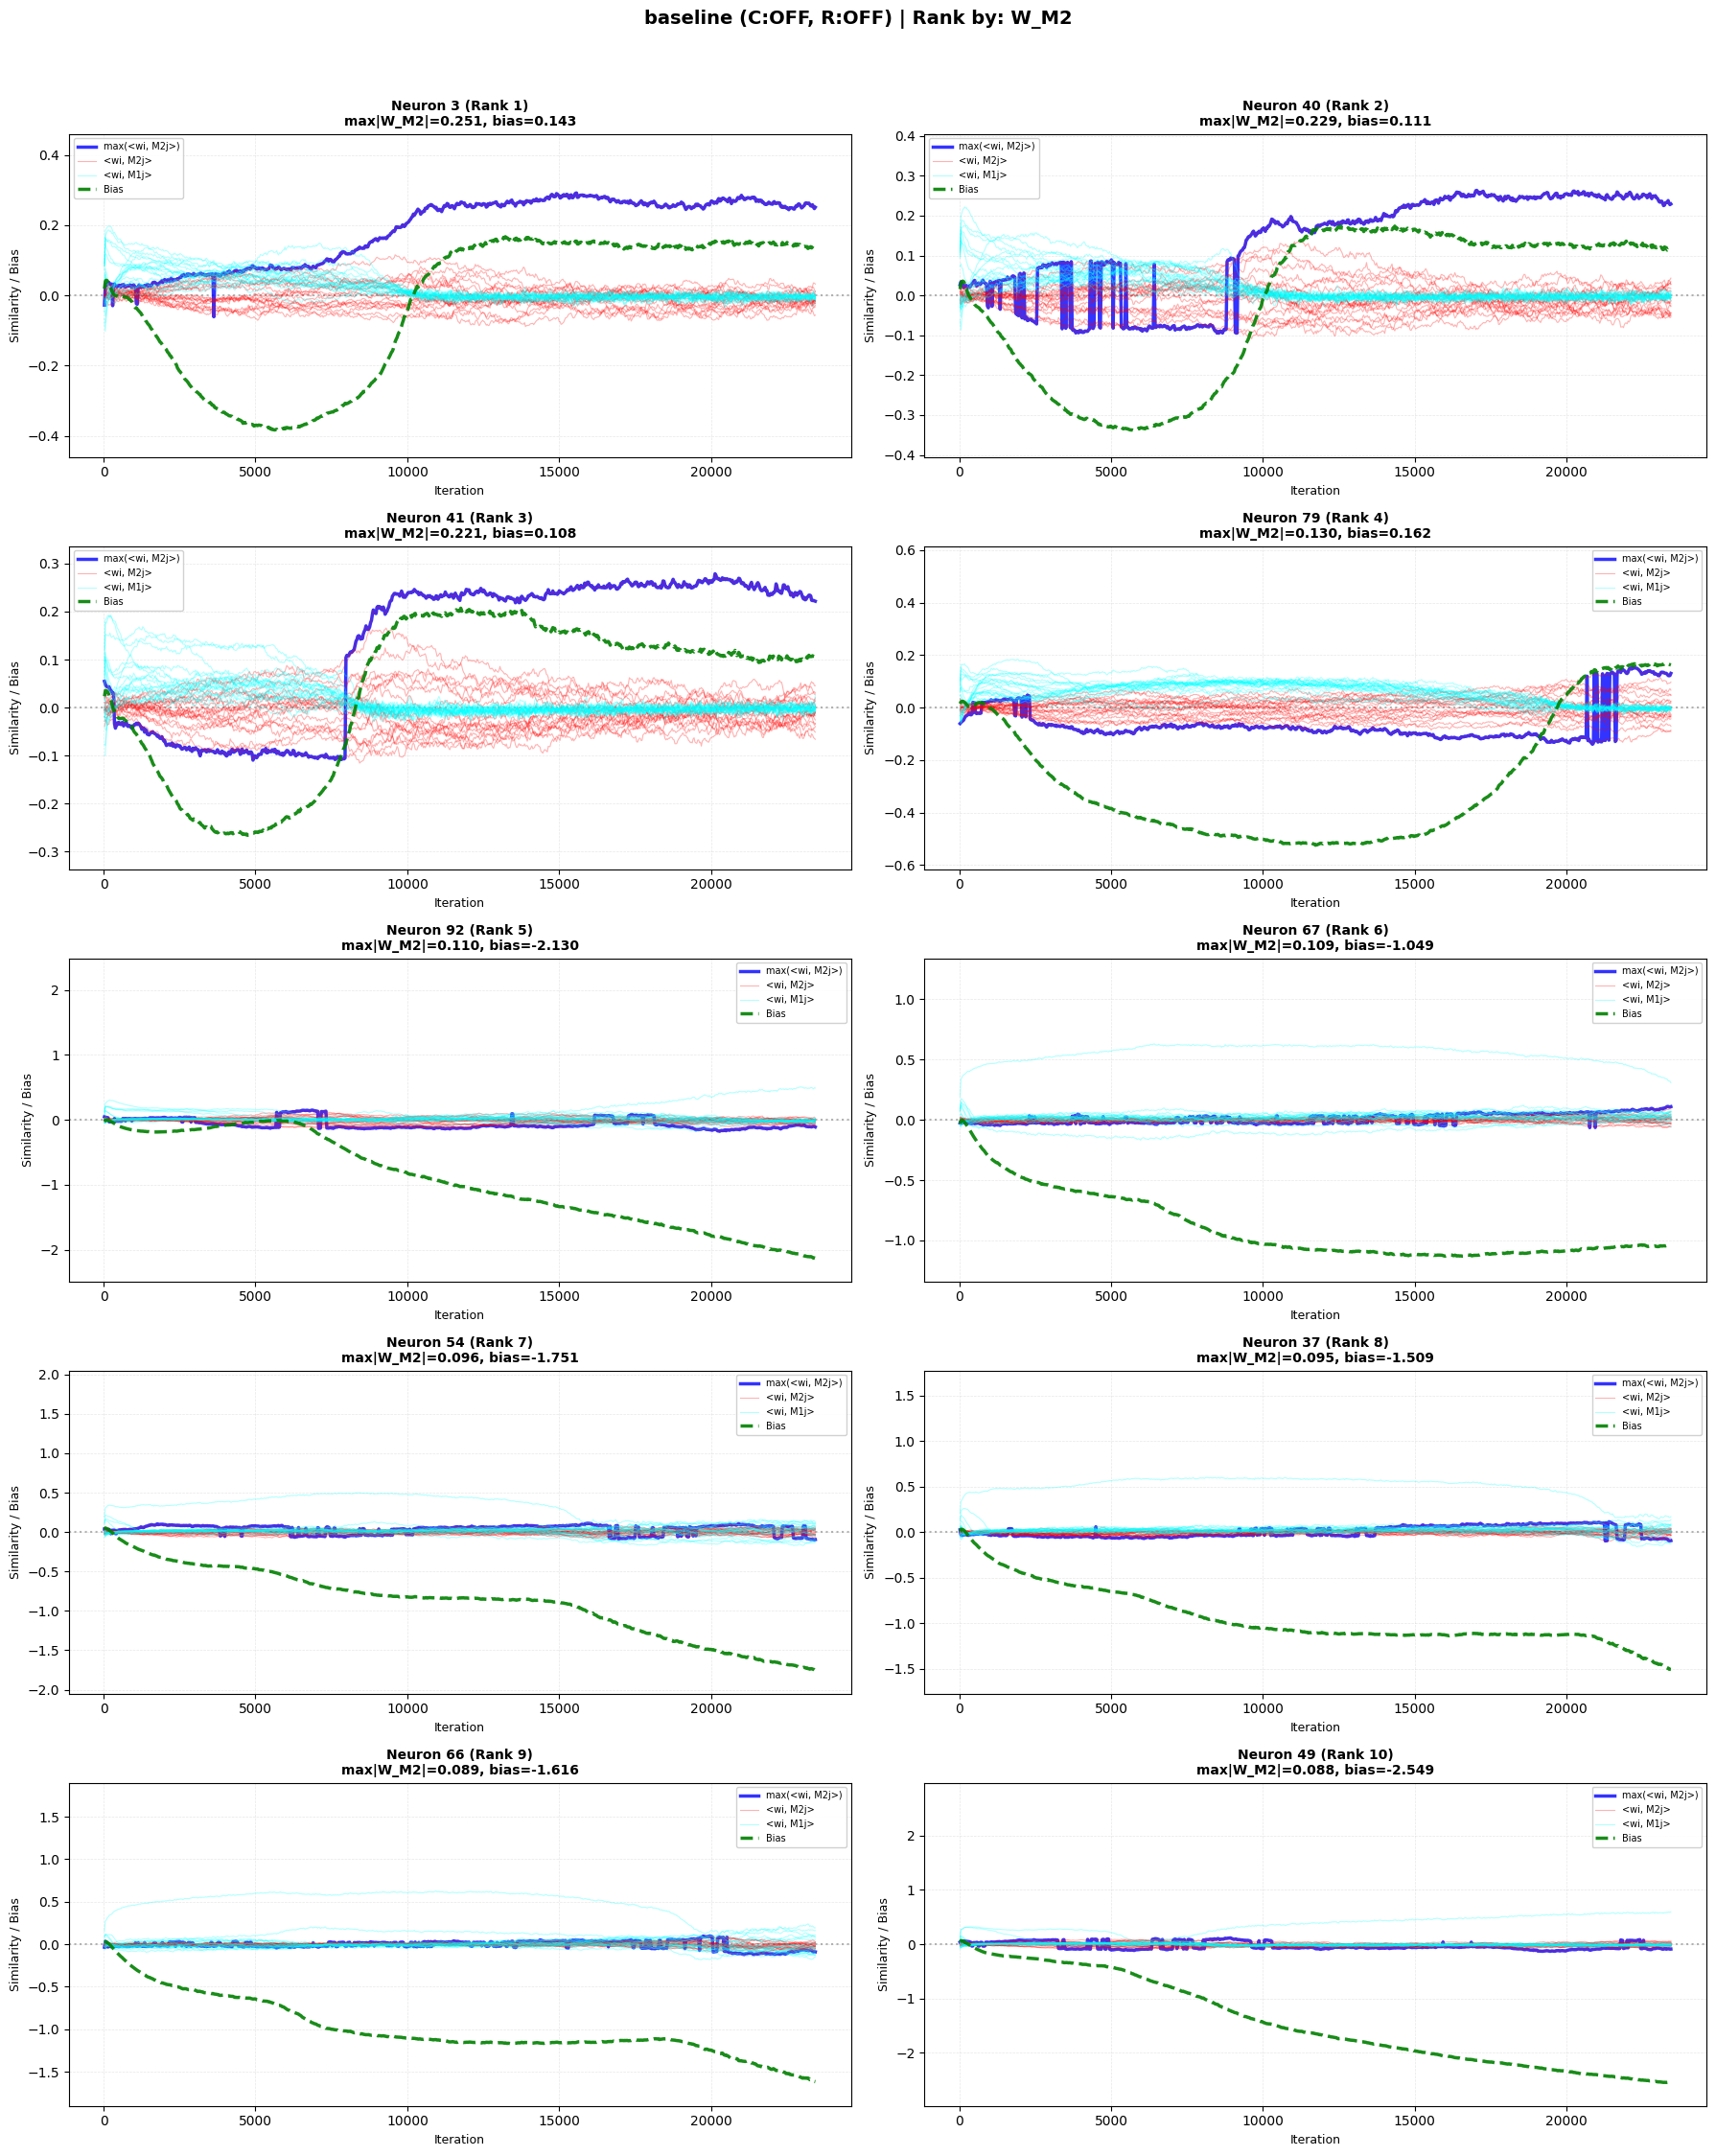

In [61]:
# baseline | W_M2 + W_M1
if 'baseline' in all_data_w_m2 and all_data_w_m2['baseline']:
    fig, _ = plot_comparison(all_data_w_m2['baseline'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='baseline (C:OFF, R:OFF)',
                              plot_tertiary=plot_tertiary)
    plt.show()

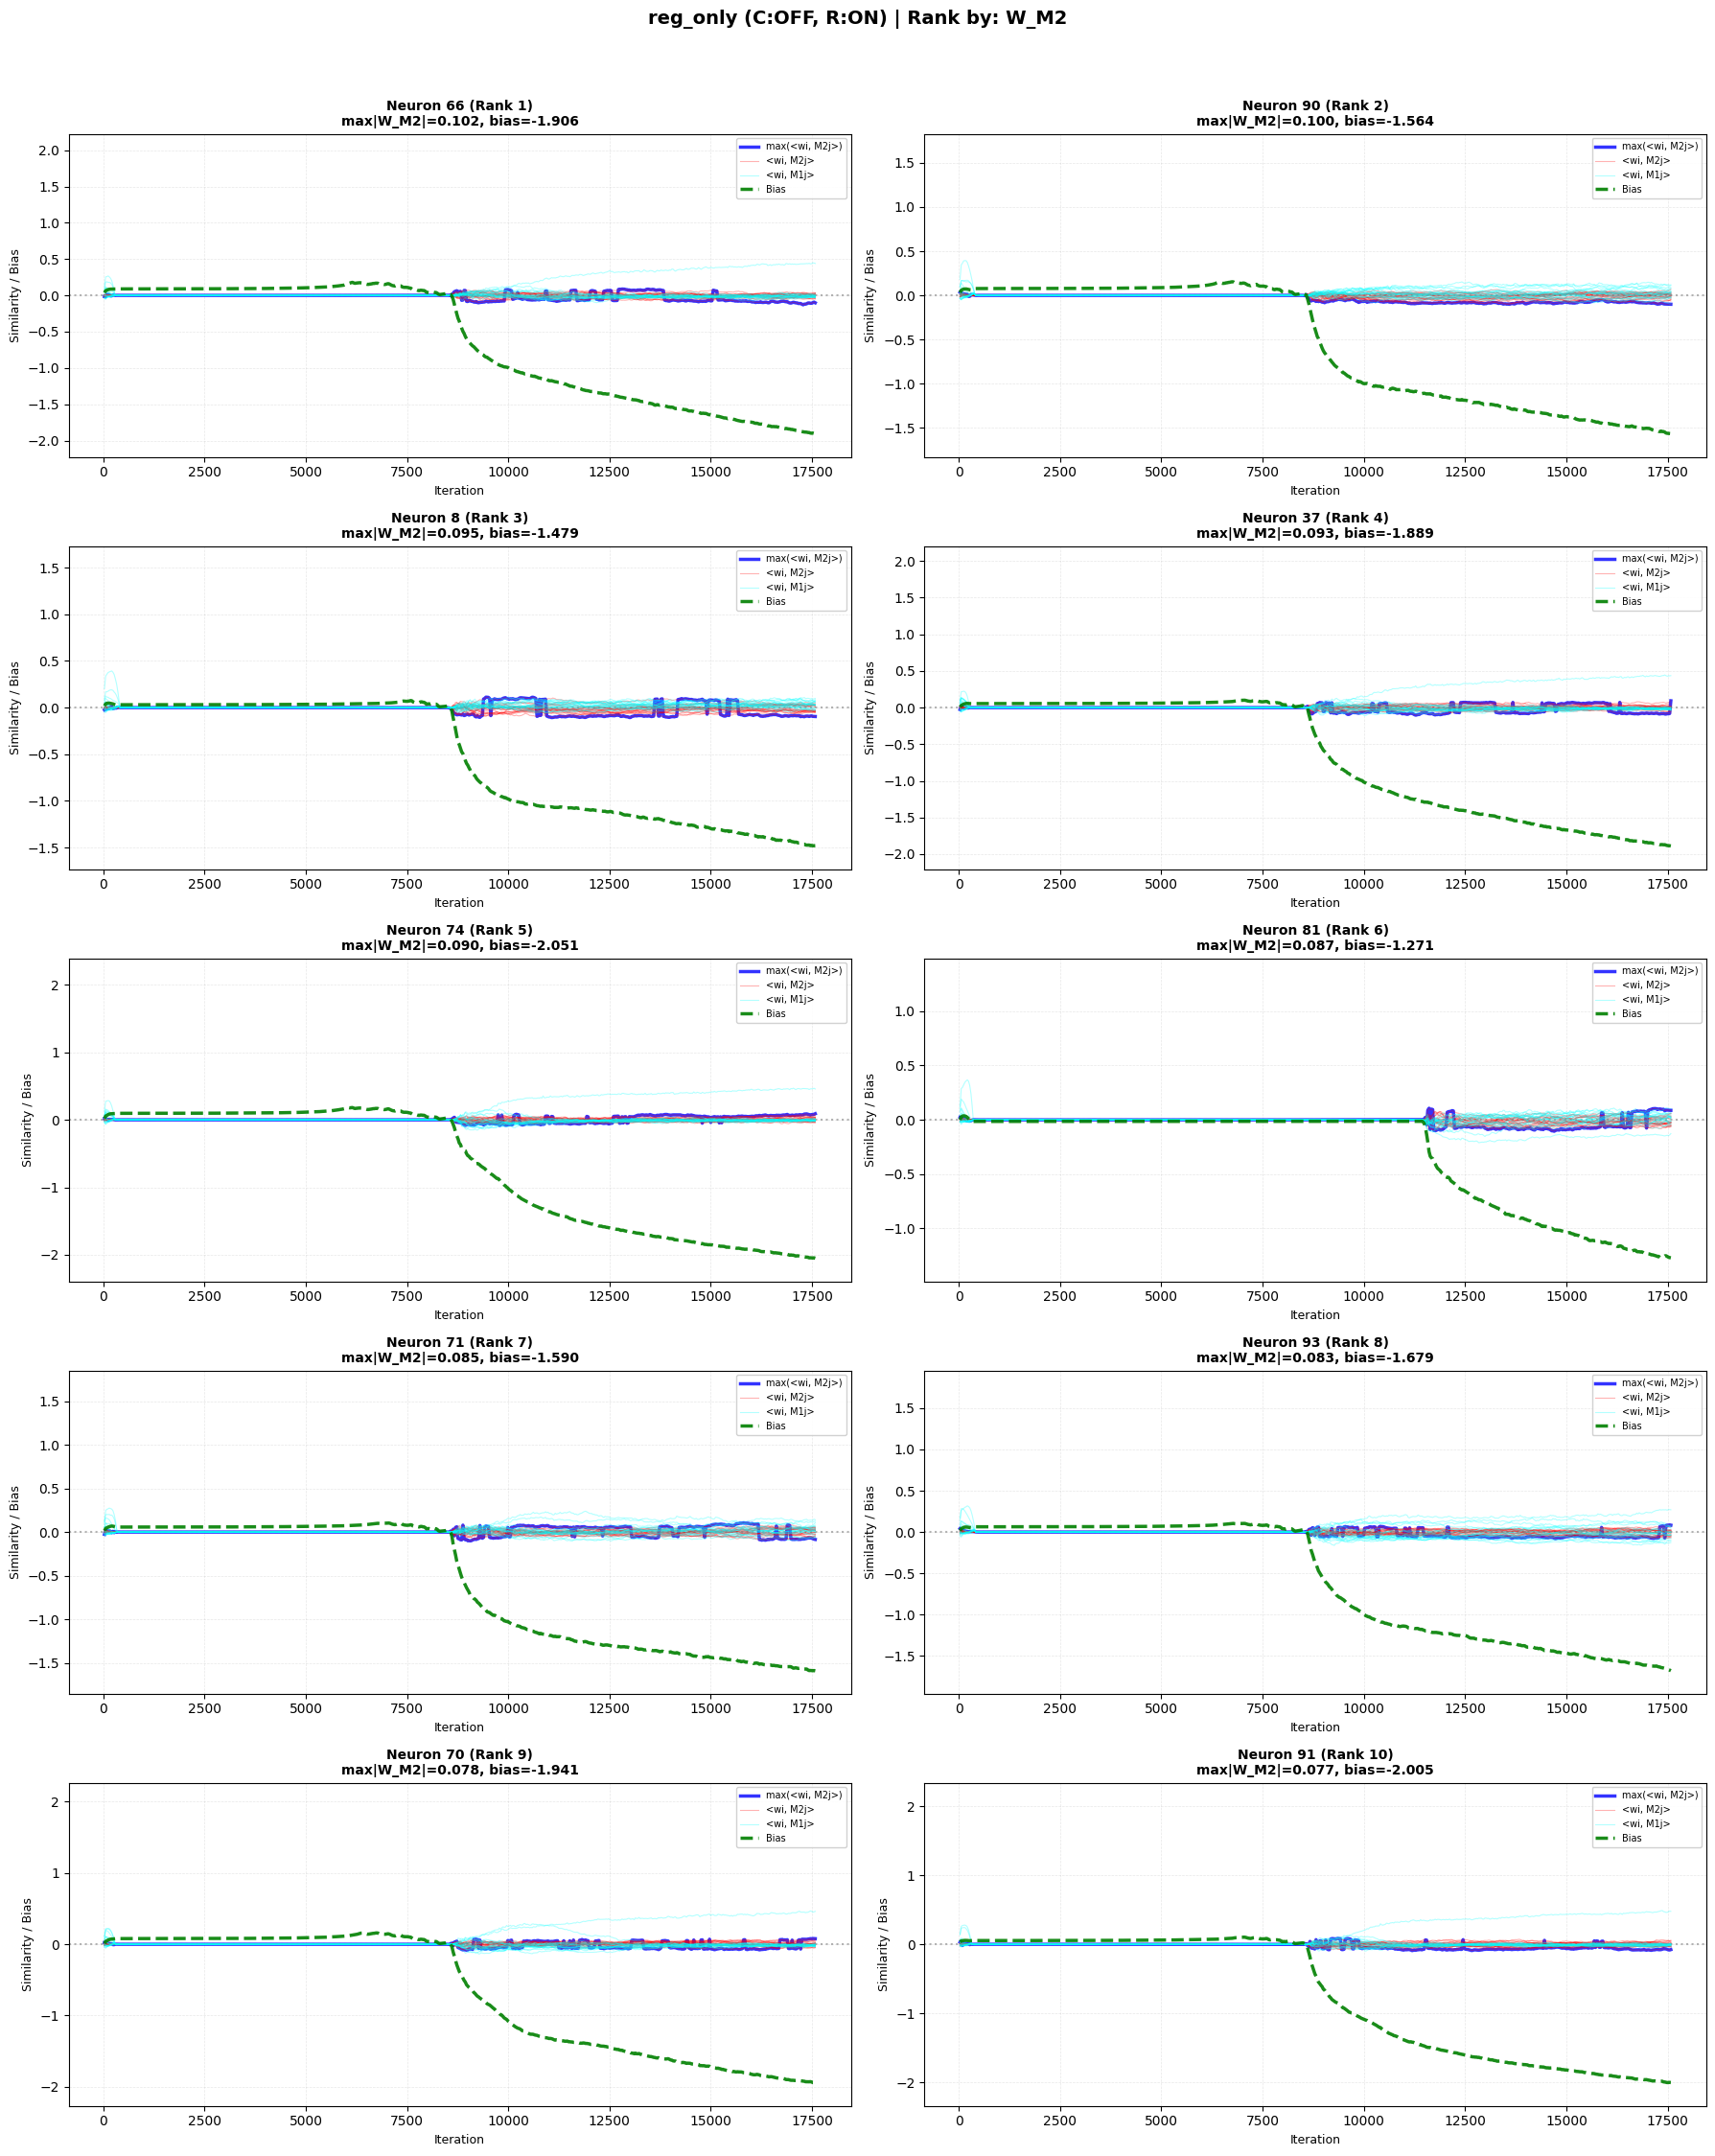

In [62]:
# reg_only | W_M2 + W_M1
if 'reg_only' in all_data_w_m2 and all_data_w_m2['reg_only']:
    fig, _ = plot_comparison(all_data_w_m2['reg_only'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='reg_only (C:OFF, R:ON)',
                              plot_tertiary=plot_tertiary)
    plt.show()

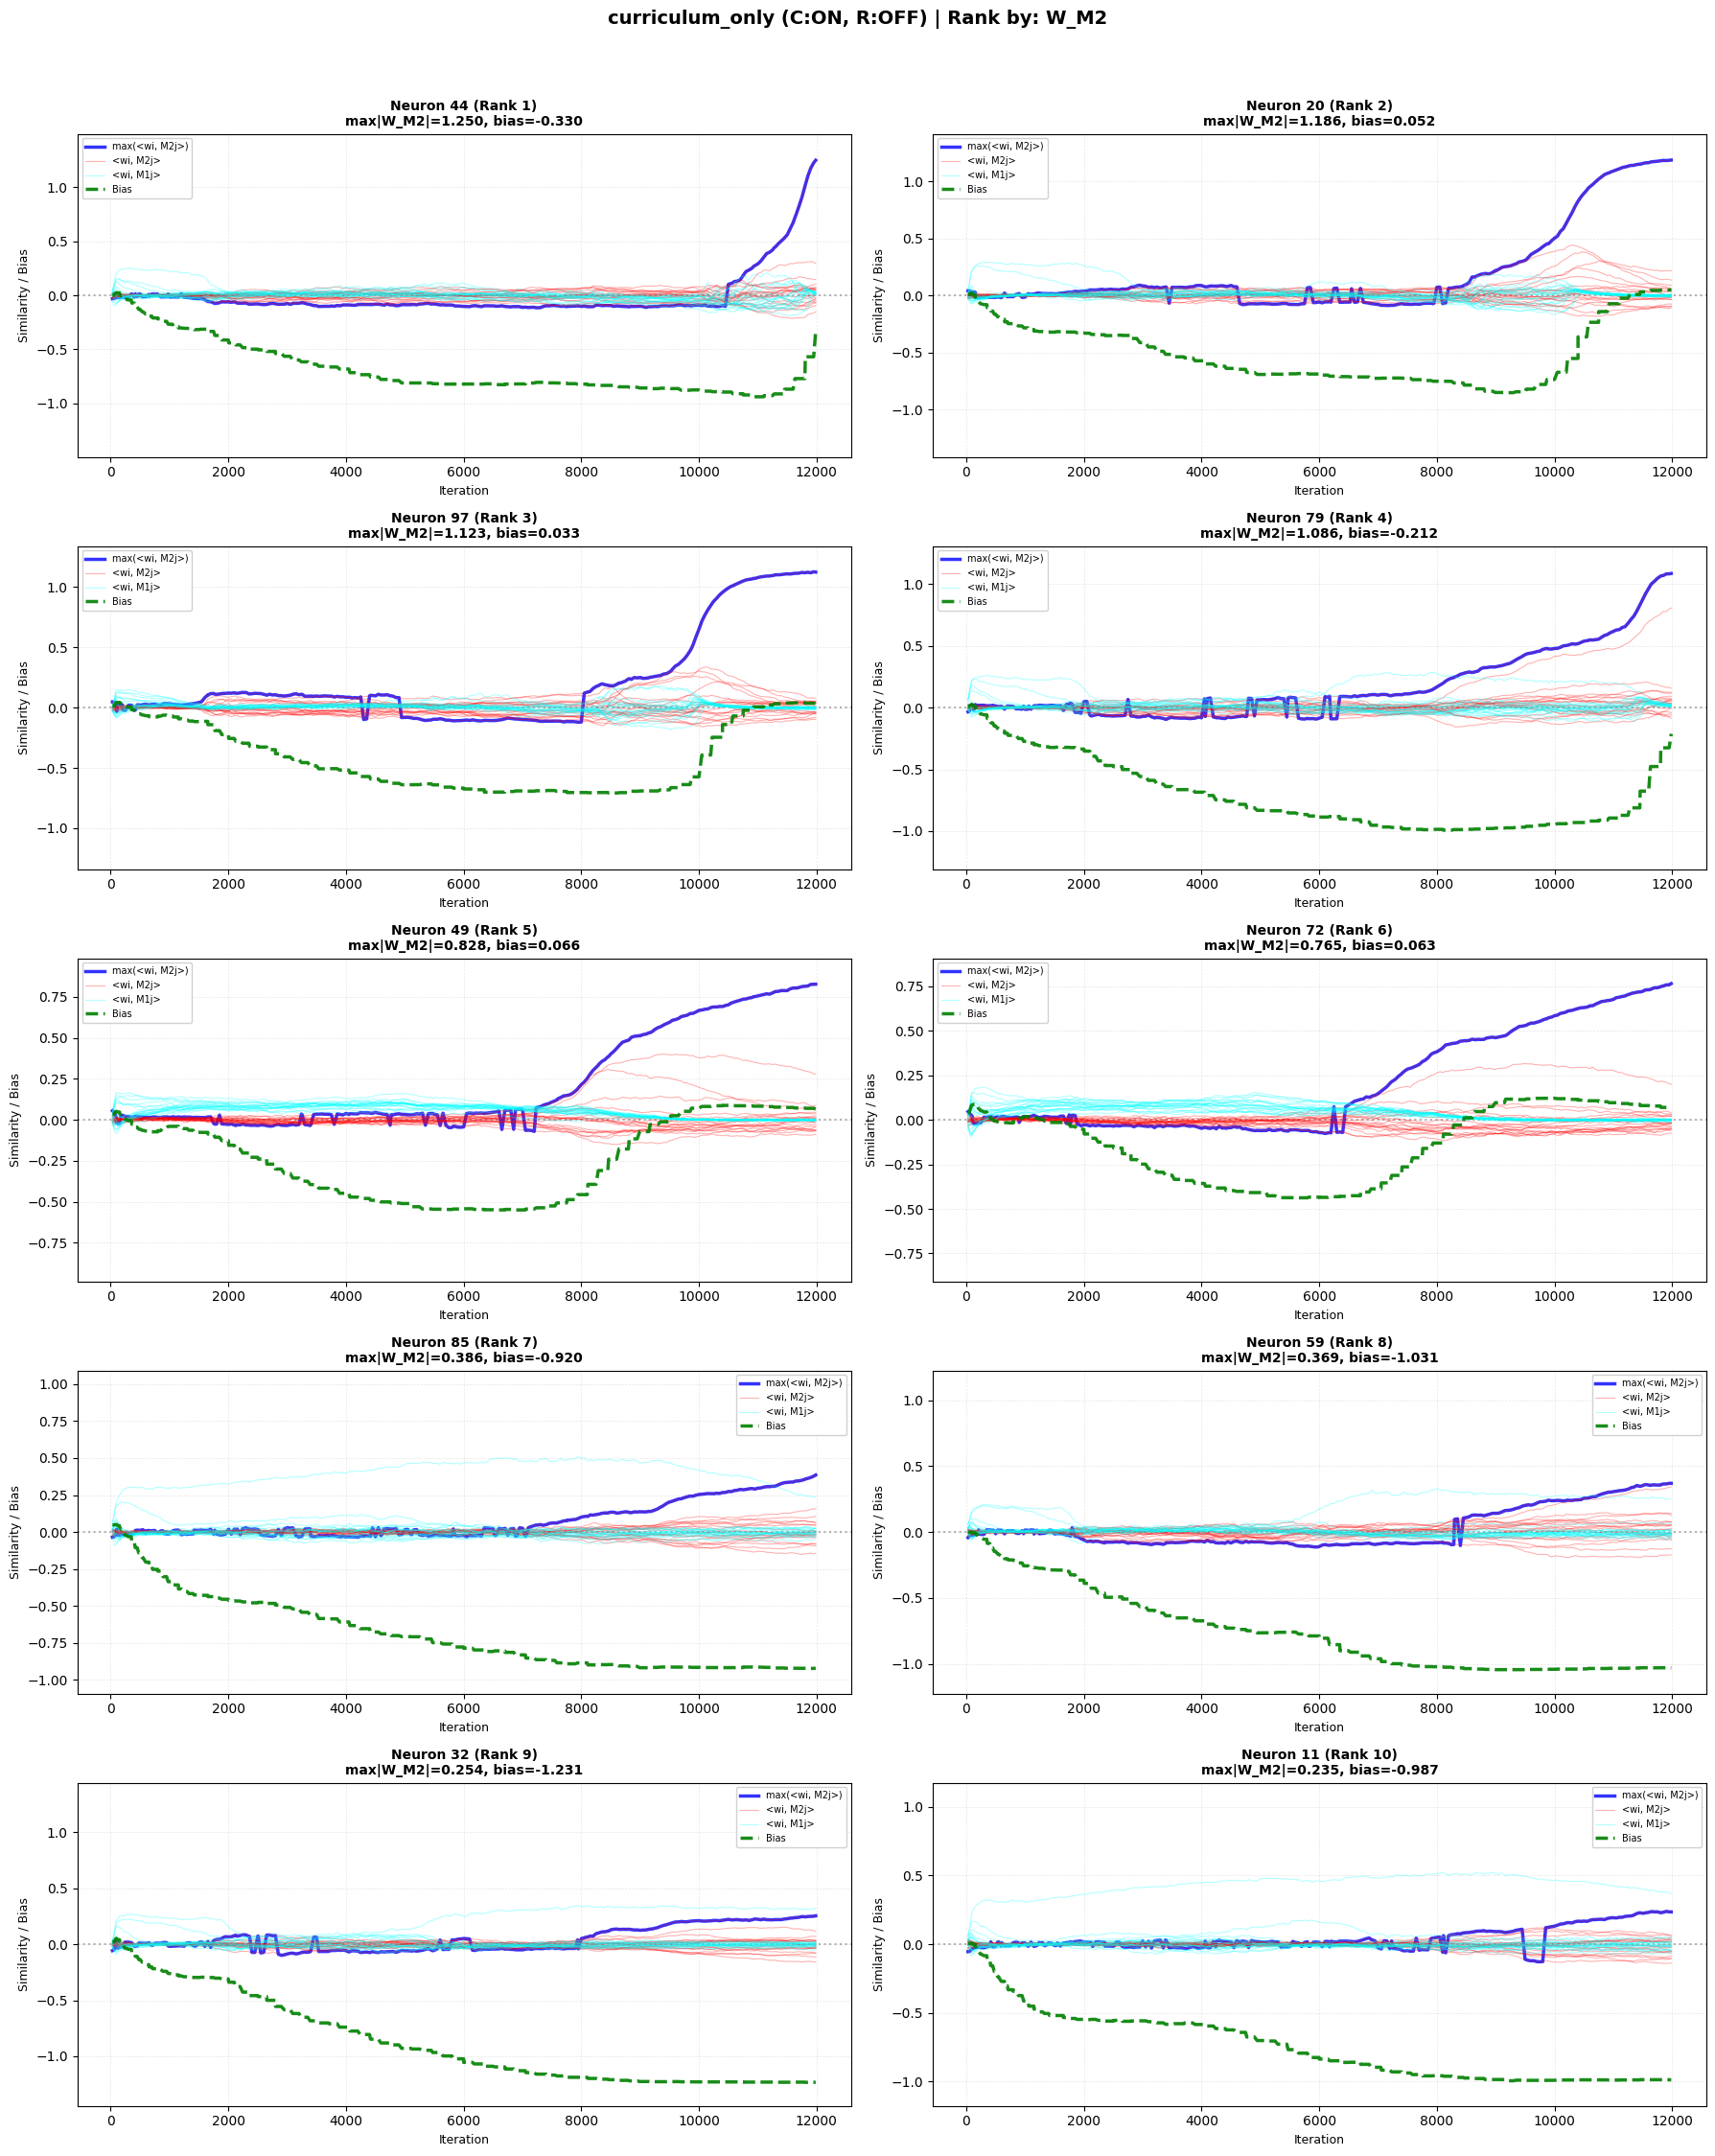

In [63]:
# curriculum_only | W_M2 + W_M1
if 'curriculum_only' in all_data_w_m2 and all_data_w_m2['curriculum_only']:
    fig, _ = plot_comparison(all_data_w_m2['curriculum_only'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='curriculum_only (C:ON, R:OFF)',
                              plot_tertiary=plot_tertiary)
    plt.show()

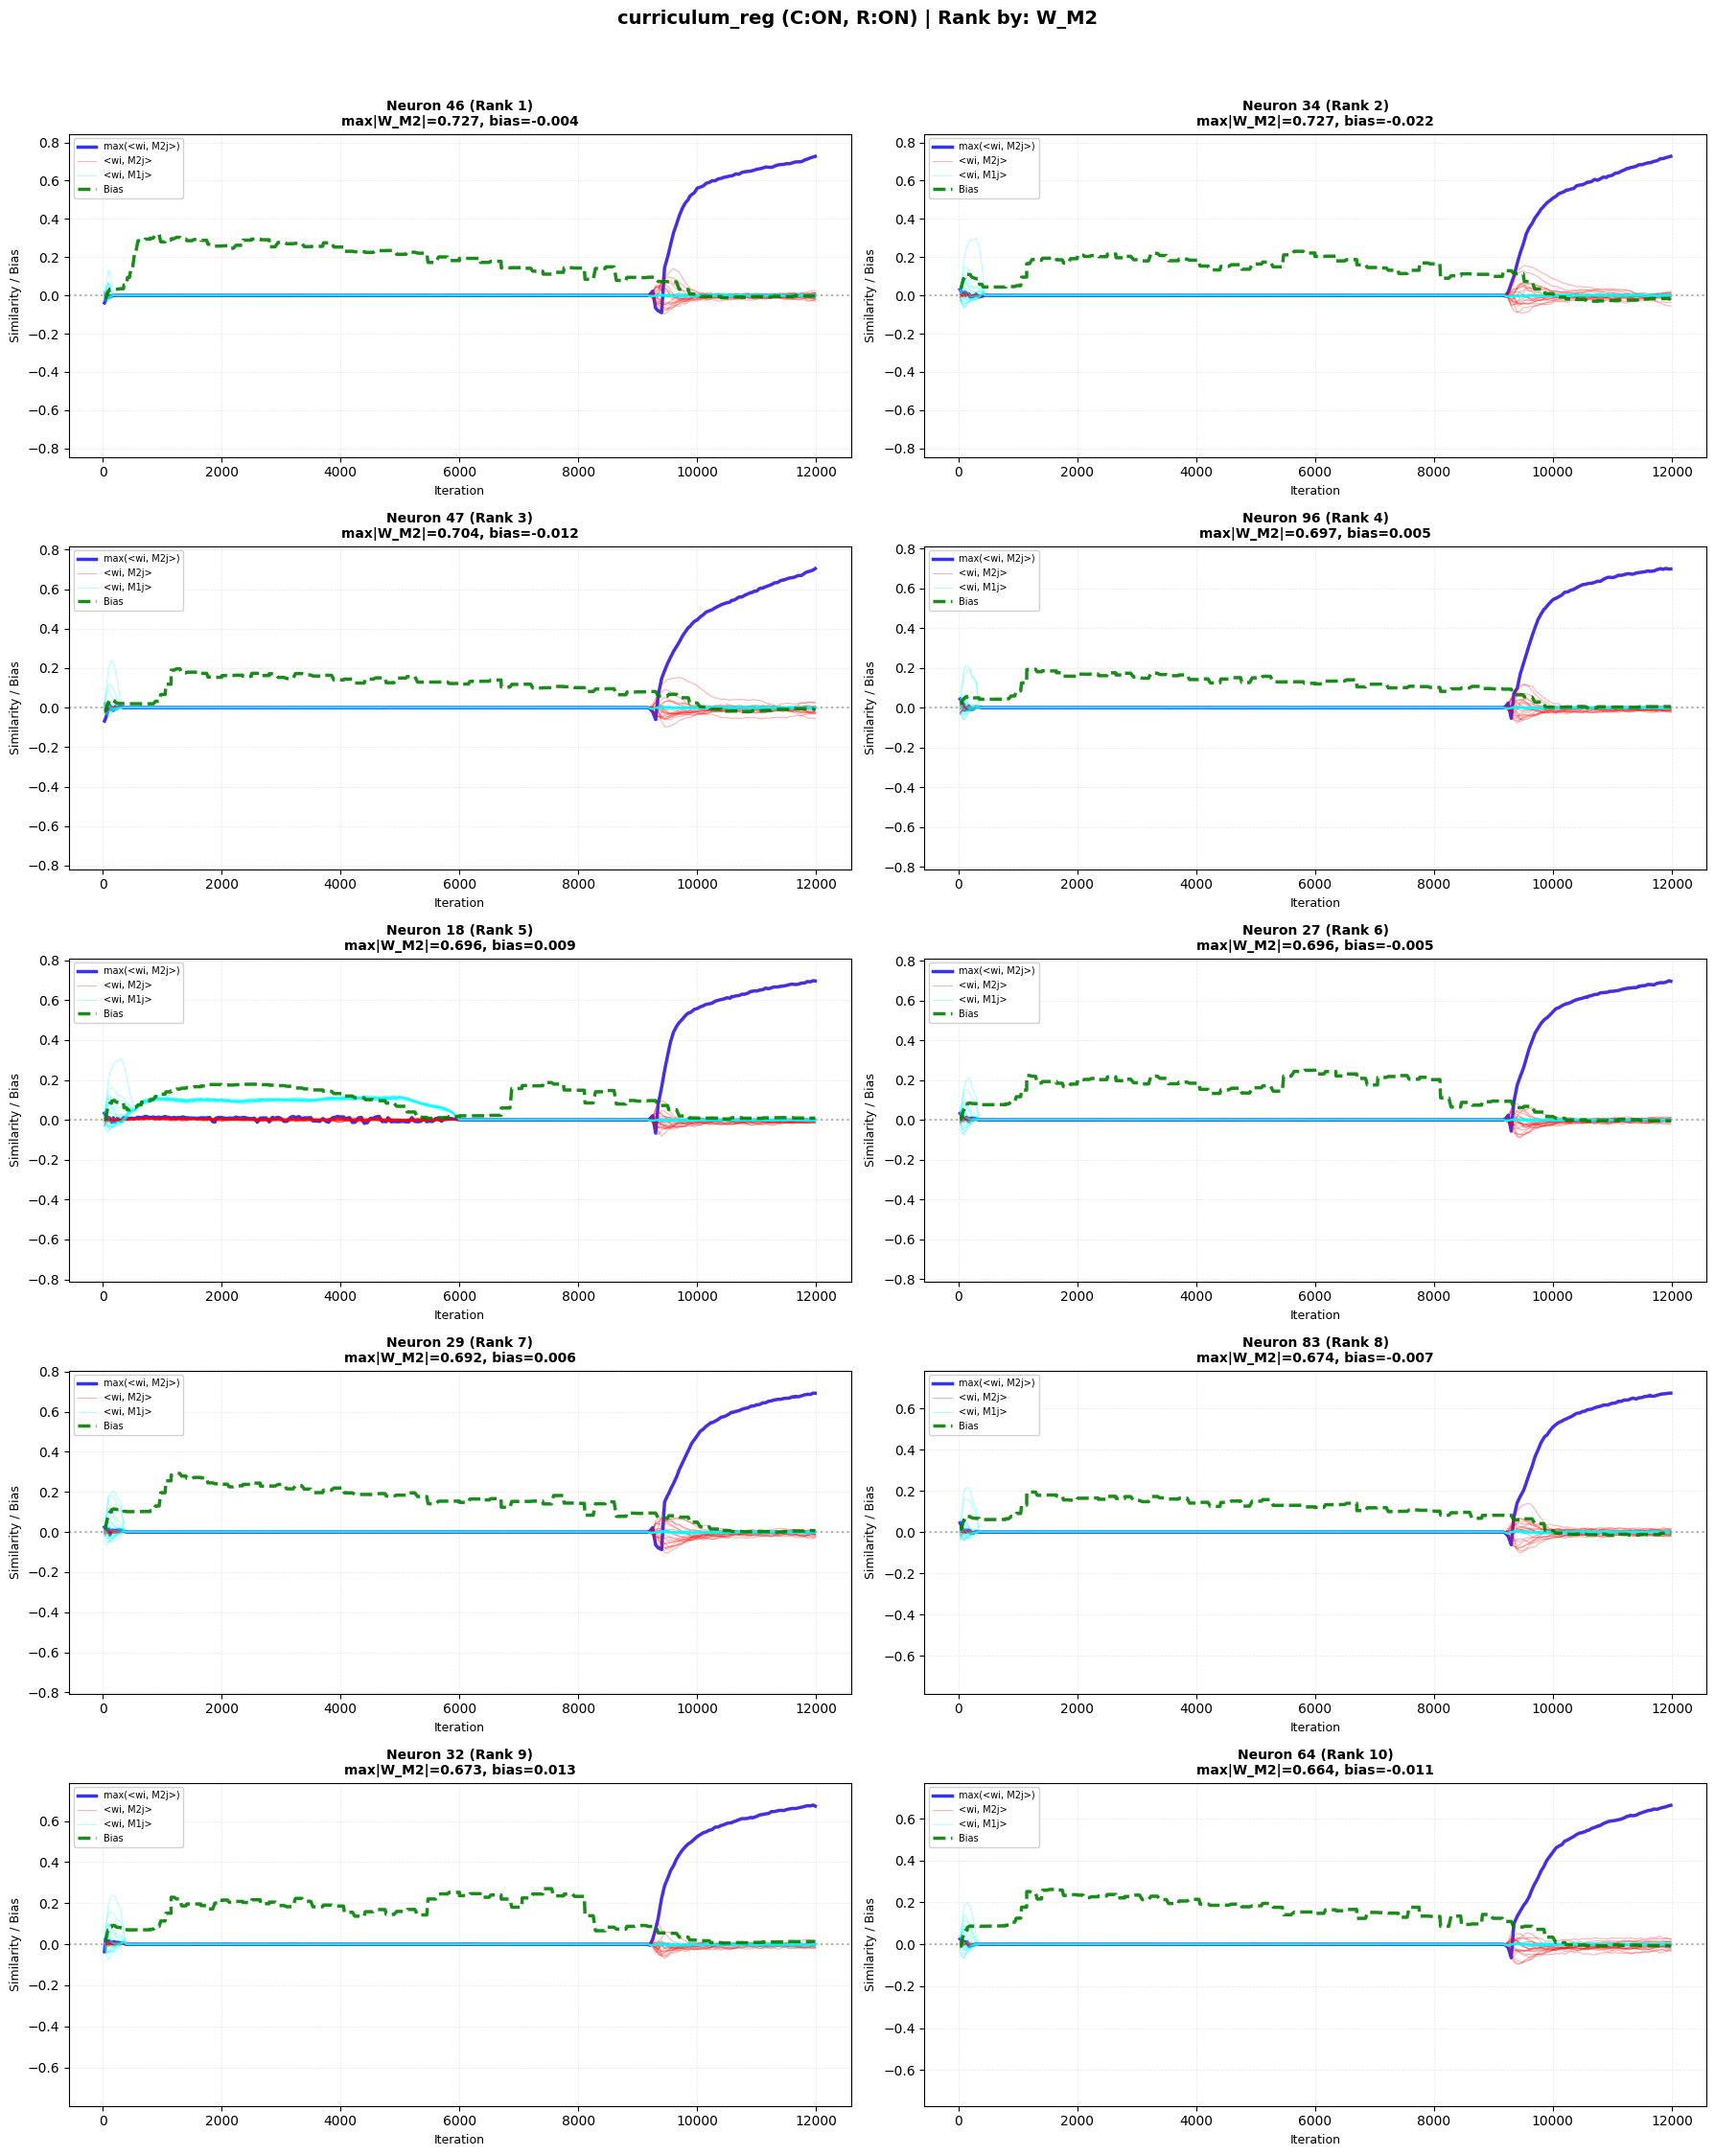

In [64]:
# curriculum_reg | W_M2 + W_M1
if 'curriculum_reg' in all_data_w_m2 and all_data_w_m2['curriculum_reg']:
    fig, _ = plot_comparison(all_data_w_m2['curriculum_reg'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='curriculum_reg (C:ON, R:ON)',
                              plot_tertiary=plot_tertiary)
    plt.show()


sparsity_only | Top 10 by max|W_M2|
Rank  1: Neuron  75 | sim=0.1880 (+) | bias=-0.0720
Rank  2: Neuron  50 | sim=0.1561 (-) | bias=-0.8177
Rank  3: Neuron  99 | sim=0.1121 (-) | bias=-0.9177
Rank  4: Neuron  70 | sim=0.1067 (+) | bias=-0.9307
Rank  5: Neuron  95 | sim=0.0859 (-) | bias=-0.7890
Rank  6: Neuron  88 | sim=0.0842 (+) | bias=-0.8741
Rank  7: Neuron  63 | sim=0.0681 (-) | bias=-1.0914
Rank  8: Neuron  89 | sim=0.0670 (-) | bias=-0.4811
Rank  9: Neuron  60 | sim=0.0659 (-) | bias=-0.9544
Rank 10: Neuron  51 | sim=0.0622 (+) | bias=-0.5871



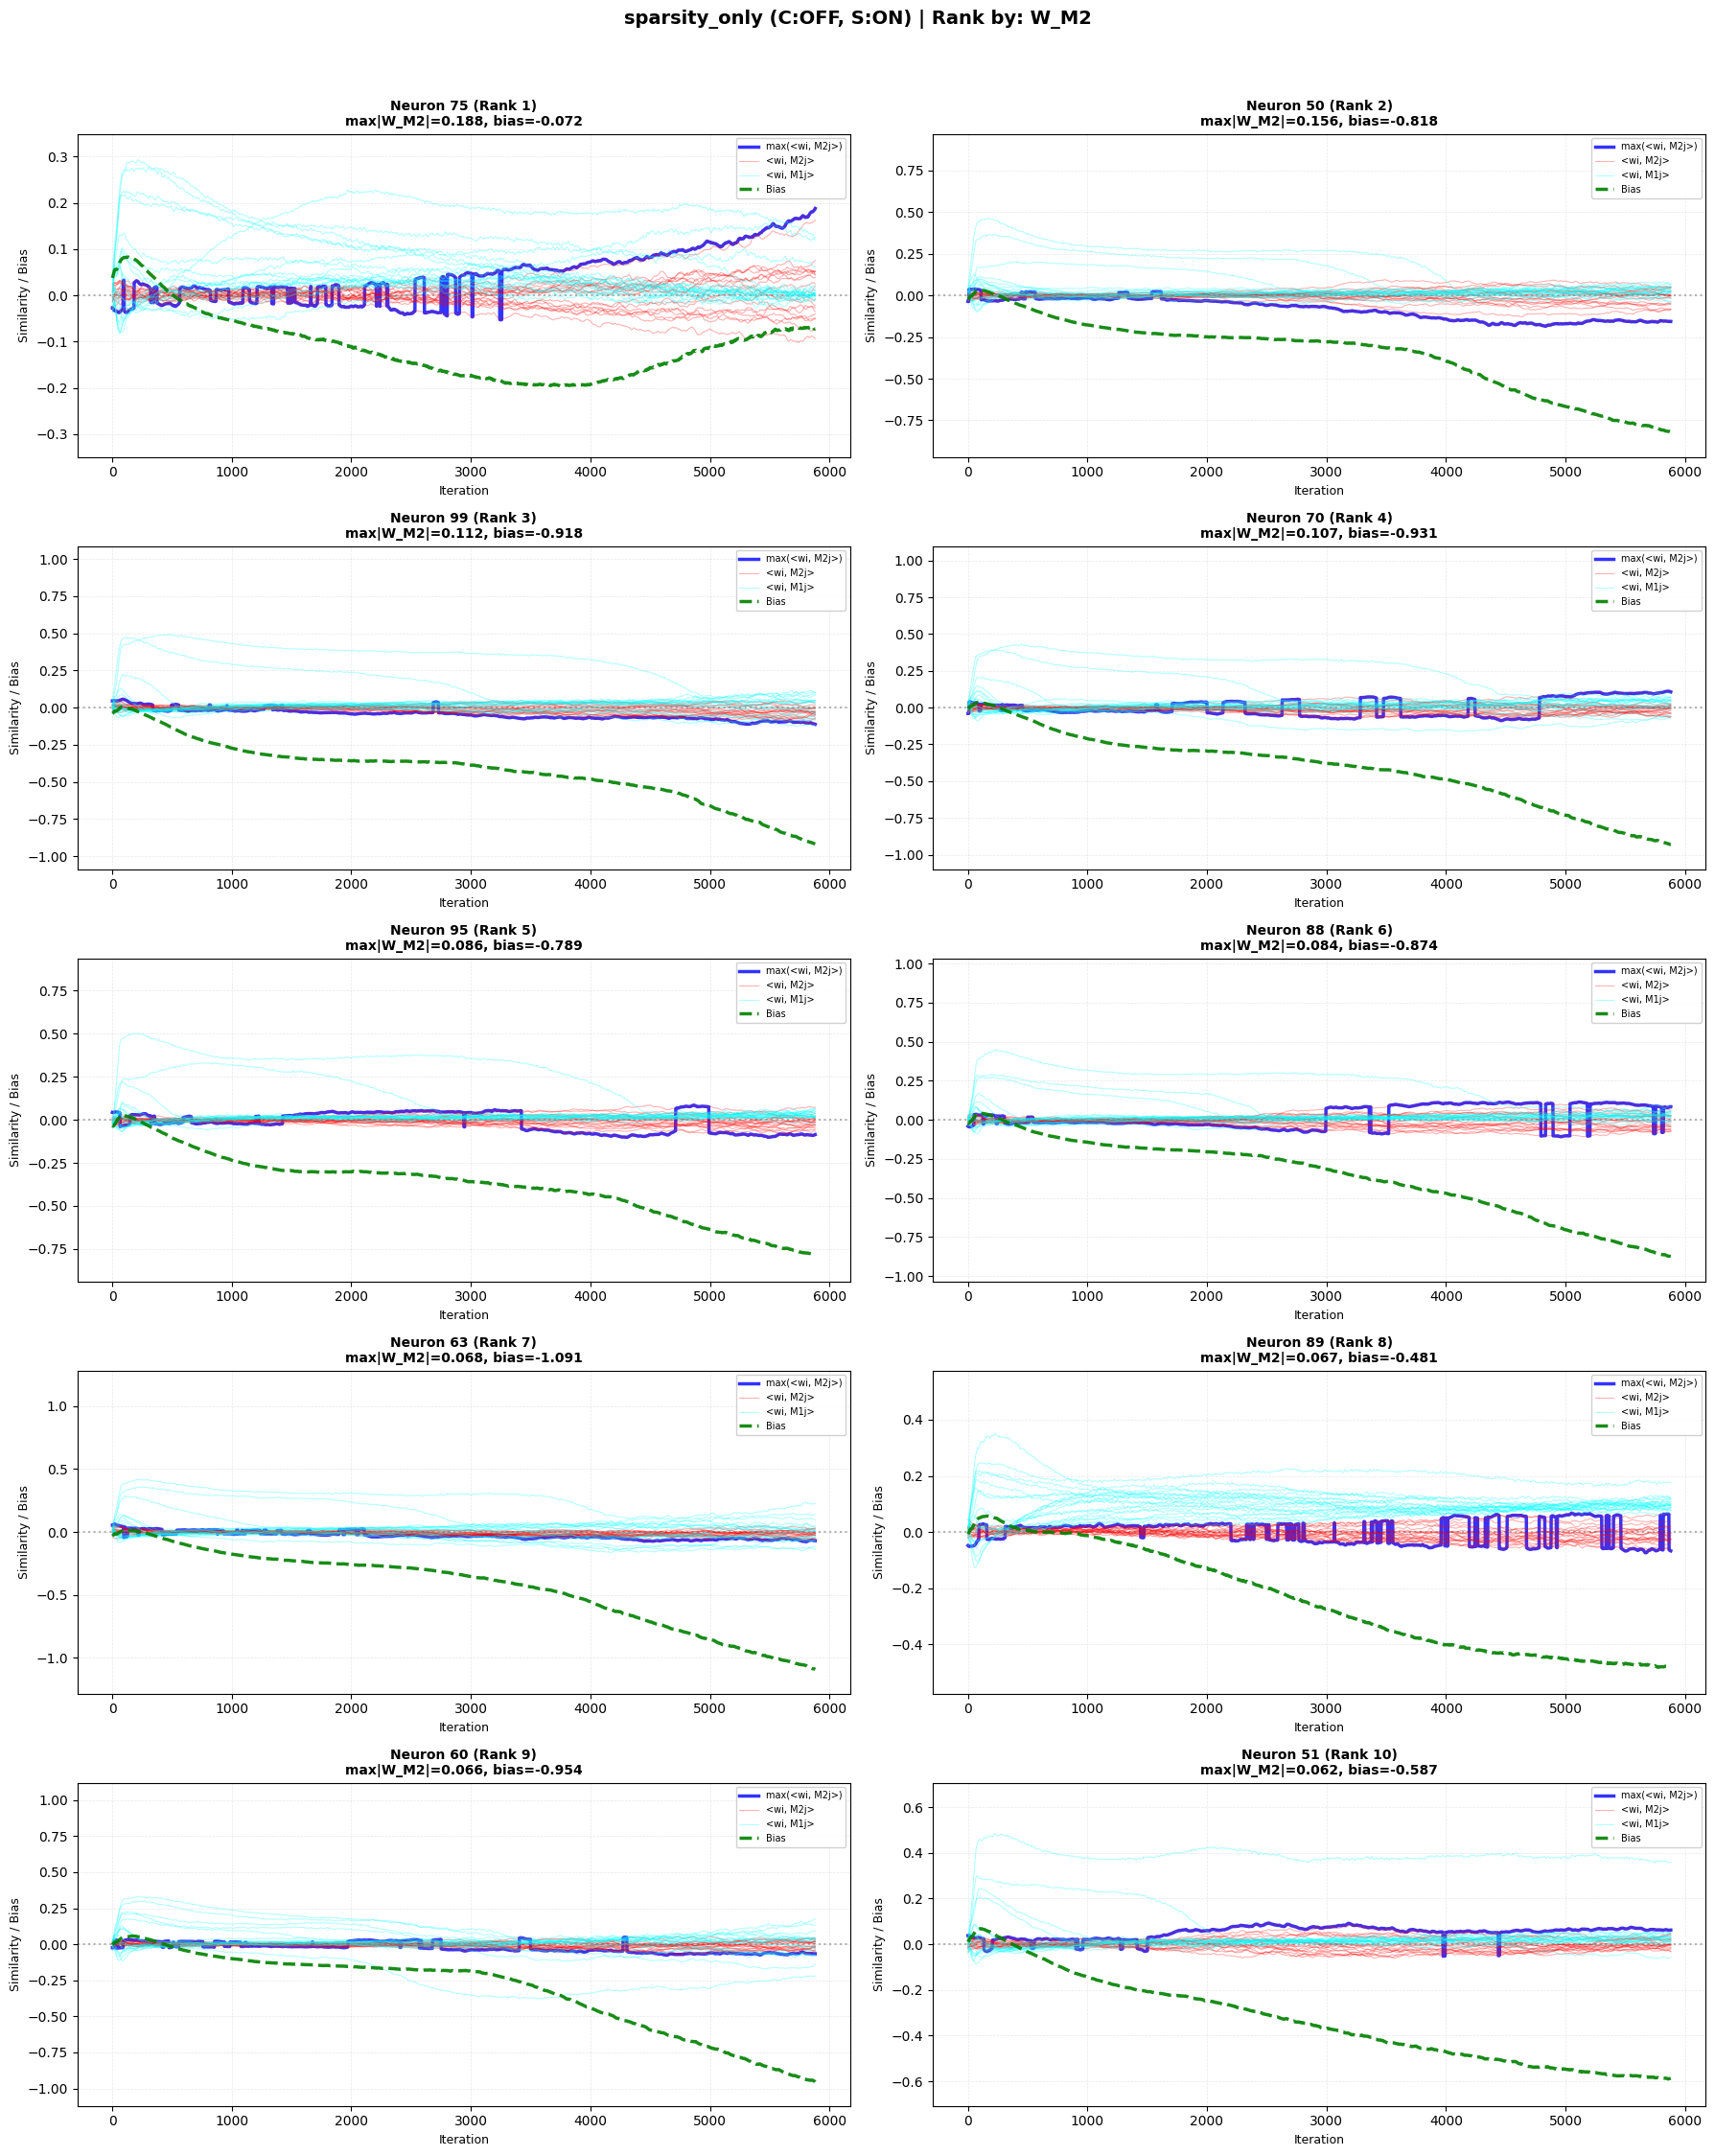

In [65]:
# sparsity_only | W_M2 + W_M1 (从旧项目加载数据)
if has_sparsity_comparison and 'sparsity_only' in old_results:
    rank_by = 'W_M2'
    plot_primary = 'W_M2'
    plot_secondary = 'W_M2'
    plot_tertiary = 'W_M1'
    
    sparsity_only_data_w_m2 = extract_top_neuron_data(old_results['sparsity_only'], rank_by, plot_primary, plot_secondary, show_bias, plot_tertiary)
    
    if sparsity_only_data_w_m2:
        print_ranking_table(sparsity_only_data_w_m2, rank_by, top_n, show_bias, 'sparsity_only')
        fig, _ = plot_comparison(sparsity_only_data_w_m2, rank_by, plot_primary, plot_secondary, 
                                  show_bias, top_n, figsize_single, title_prefix='sparsity_only (C:OFF, S:ON)',
                                  plot_tertiary=plot_tertiary)
        plt.show()


curriculum_sparsity | Top 10 by max|W_M2|
Rank  1: Neuron  35 | sim=1.0553 (+) | bias=-0.5248
Rank  2: Neuron  30 | sim=1.0407 (+) | bias=-0.5710
Rank  3: Neuron   2 | sim=1.0117 (+) | bias=0.0055
Rank  4: Neuron  52 | sim=0.8976 (+) | bias=-0.0710
Rank  5: Neuron  45 | sim=0.8639 (+) | bias=-0.0073
Rank  6: Neuron  47 | sim=0.8441 (+) | bias=-0.0083
Rank  7: Neuron  64 | sim=0.8370 (+) | bias=-0.0739
Rank  8: Neuron  55 | sim=0.8164 (+) | bias=-0.0015
Rank  9: Neuron  49 | sim=0.7636 (+) | bias=0.0033
Rank 10: Neuron  61 | sim=0.7610 (+) | bias=0.0073



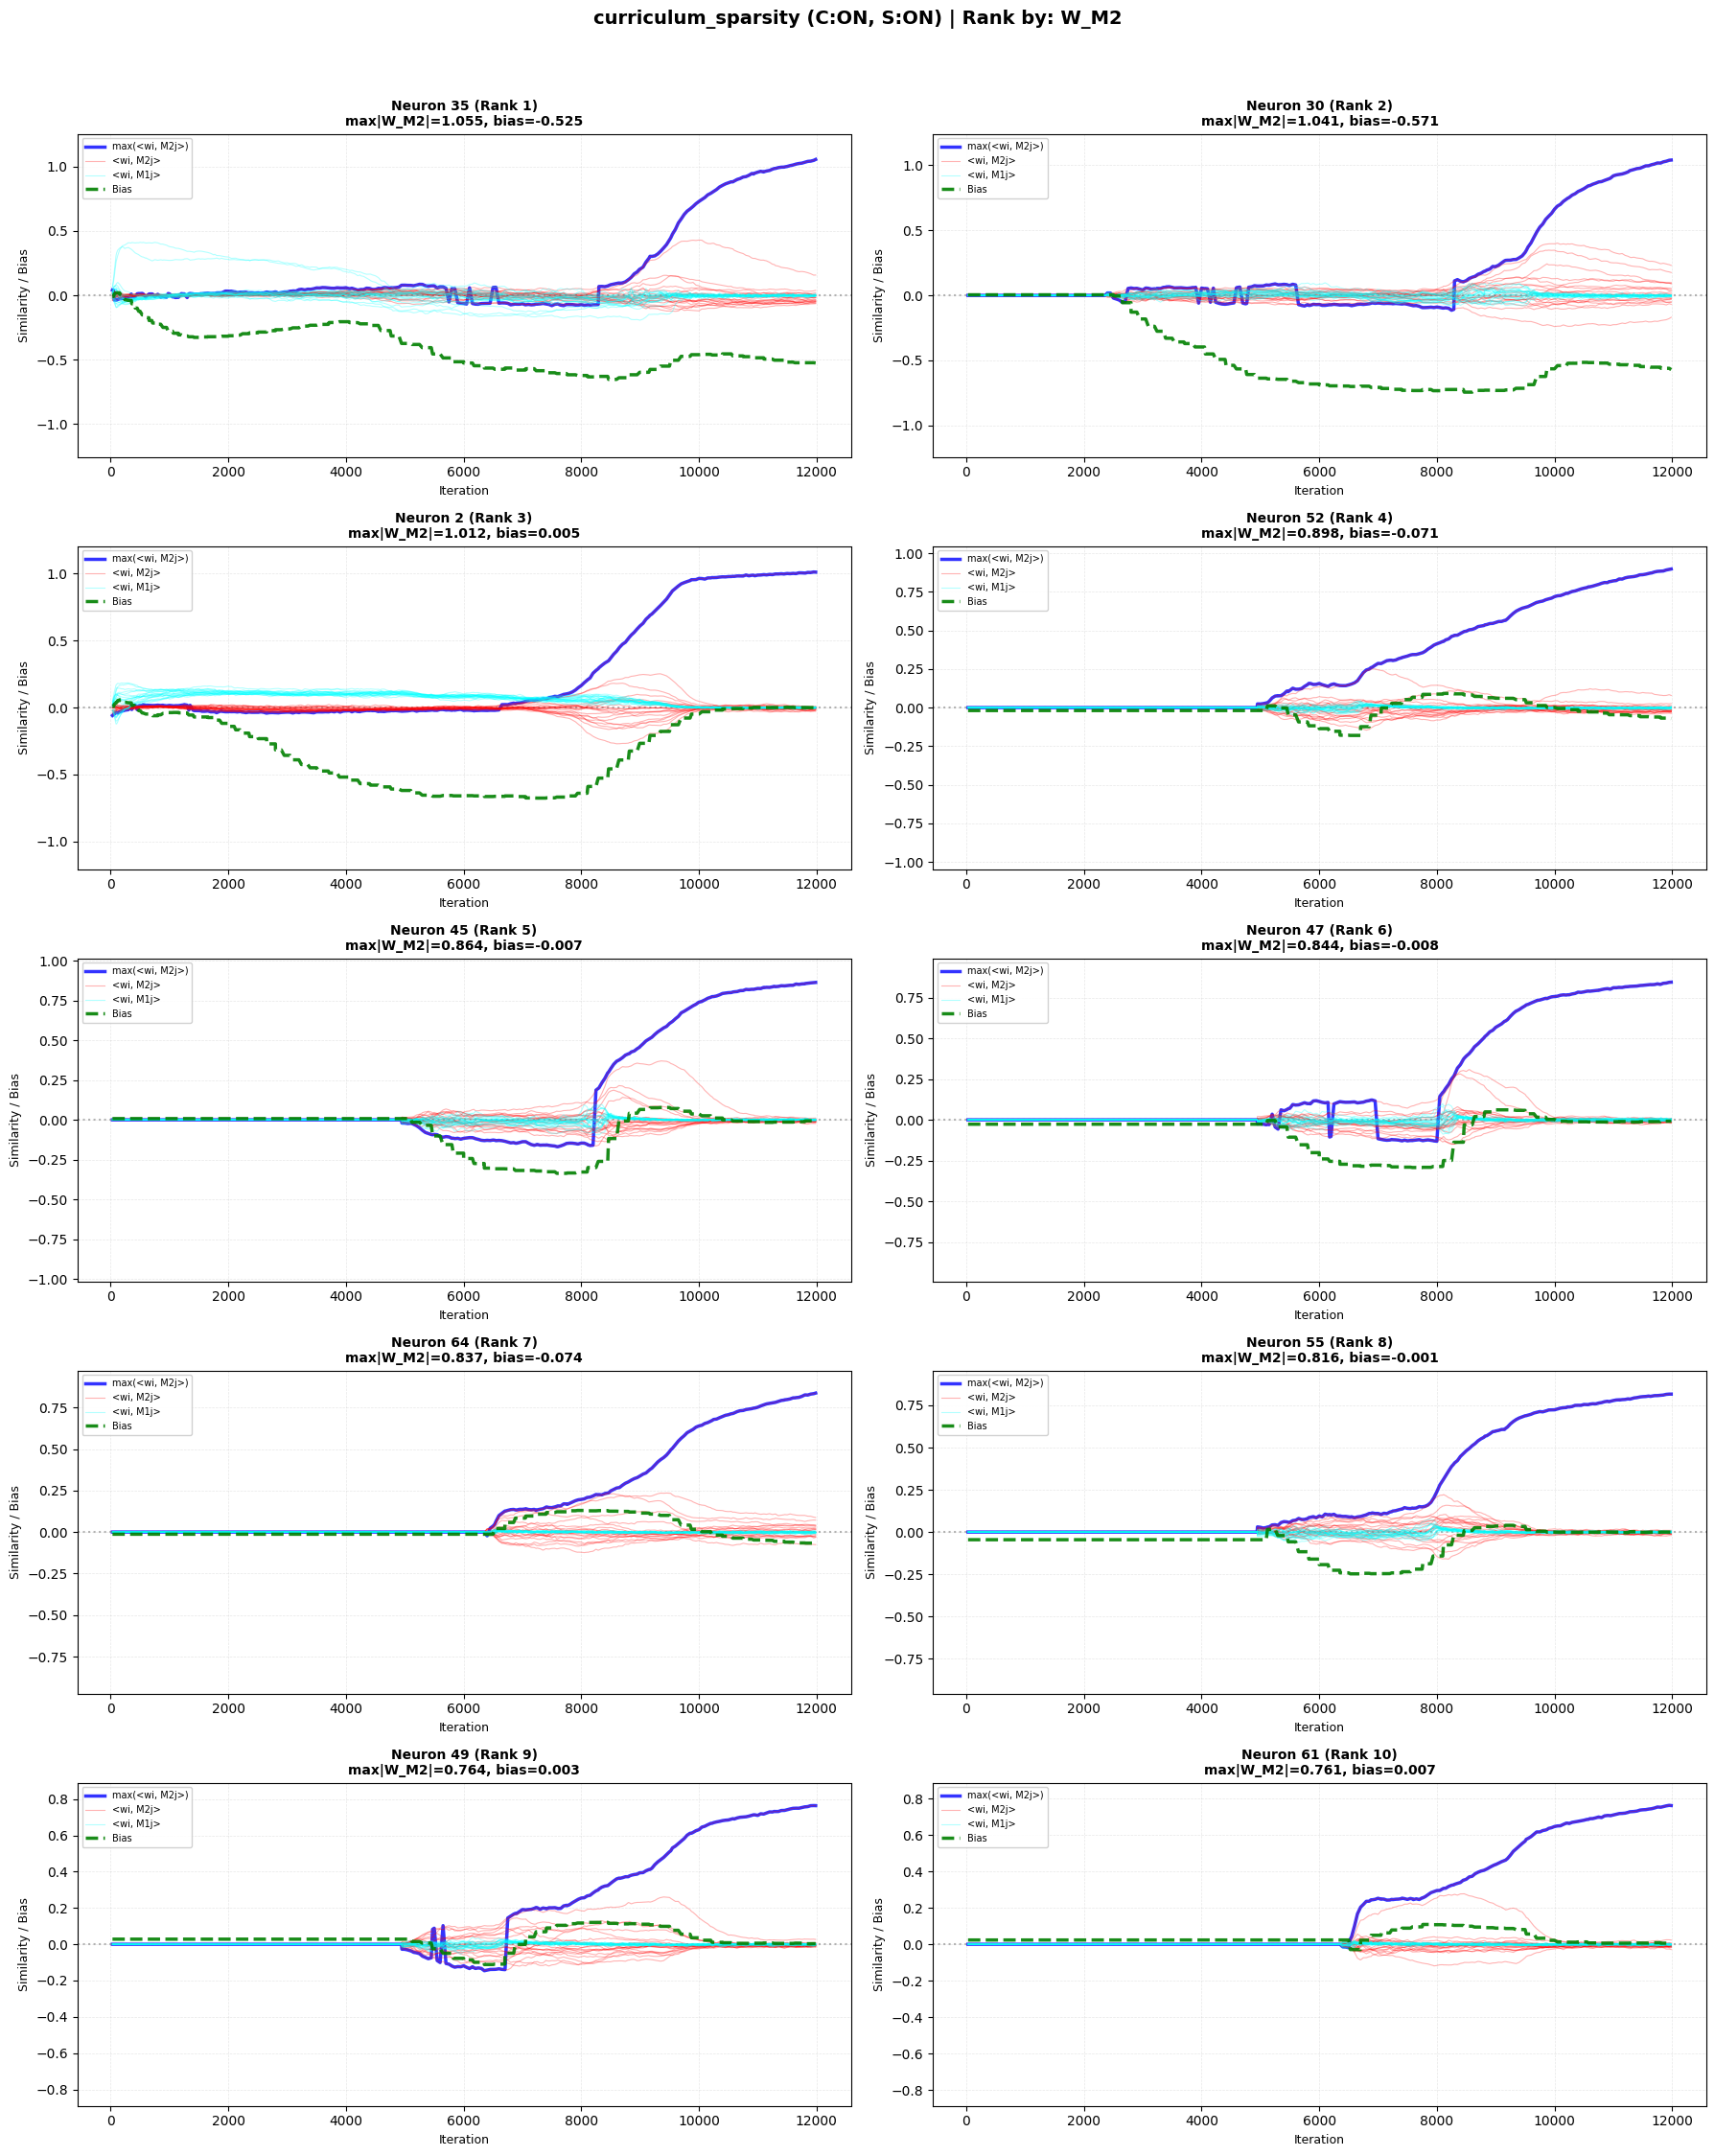

In [66]:
# curriculum_sparsity | W_M2 + W_M1 (从旧项目加载数据)
if has_sparsity_comparison and 'curriculum_sparsity' in old_results:
    rank_by = 'W_M2'
    plot_primary = 'W_M2'
    plot_secondary = 'W_M2'
    plot_tertiary = 'W_M1'
    
    curriculum_sparsity_data_w_m2 = extract_top_neuron_data(old_results['curriculum_sparsity'], rank_by, plot_primary, plot_secondary, show_bias, plot_tertiary)
    
    if curriculum_sparsity_data_w_m2:
        print_ranking_table(curriculum_sparsity_data_w_m2, rank_by, top_n, show_bias, 'curriculum_sparsity')
        fig, _ = plot_comparison(curriculum_sparsity_data_w_m2, rank_by, plot_primary, plot_secondary, 
                                  show_bias, top_n, figsize_single, title_prefix='curriculum_sparsity (C:ON, S:ON)',
                                  plot_tertiary=plot_tertiary)
        plt.show()

---
## Rank by W_M1

In [67]:
rank_by = 'W_M1'
plot_primary = 'W_M1'
plot_secondary = 'W_M1'
plot_tertiary = 'W_M2'

# 提取并打印排名表
all_data_w_m1 = {}
for name, results in all_results.items():
    data = extract_top_neuron_data(results, rank_by, plot_primary, plot_secondary, show_bias, plot_tertiary)
    all_data_w_m1[name] = data
    if data:
        print_ranking_table(data, rank_by, top_n, show_bias, name)


baseline | Top 10 by max|W_M1|
Rank  1: Neuron  46 | sim=1.2546 (+) | bias=-2.3208
Rank  2: Neuron   1 | sim=1.2520 (+) | bias=-2.3878
Rank  3: Neuron  50 | sim=1.2470 (+) | bias=-2.4186
Rank  4: Neuron  86 | sim=1.2390 (+) | bias=-2.3508
Rank  5: Neuron  85 | sim=1.2355 (+) | bias=-2.3991
Rank  6: Neuron  20 | sim=1.2345 (+) | bias=-2.3160
Rank  7: Neuron  94 | sim=1.2217 (+) | bias=-2.3173
Rank  8: Neuron  47 | sim=1.2159 (+) | bias=-2.3838
Rank  9: Neuron  31 | sim=1.2128 (+) | bias=-2.3271
Rank 10: Neuron  84 | sim=1.2123 (+) | bias=-2.3523


curriculum_only | Top 10 by max|W_M1|
Rank  1: Neuron  84 | sim=1.0005 (+) | bias=-1.7527
Rank  2: Neuron  43 | sim=0.8905 (+) | bias=-1.5385
Rank  3: Neuron  61 | sim=0.8895 (+) | bias=-1.5095
Rank  4: Neuron   2 | sim=0.8827 (+) | bias=-1.5885
Rank  5: Neuron  24 | sim=0.8827 (+) | bias=-1.5611
Rank  6: Neuron  80 | sim=0.8779 (+) | bias=-1.5110
Rank  7: Neuron  57 | sim=0.8728 (+) | bias=-1.5025
Rank  8: Neuron  15 | sim=0.8653 (+) | bias=

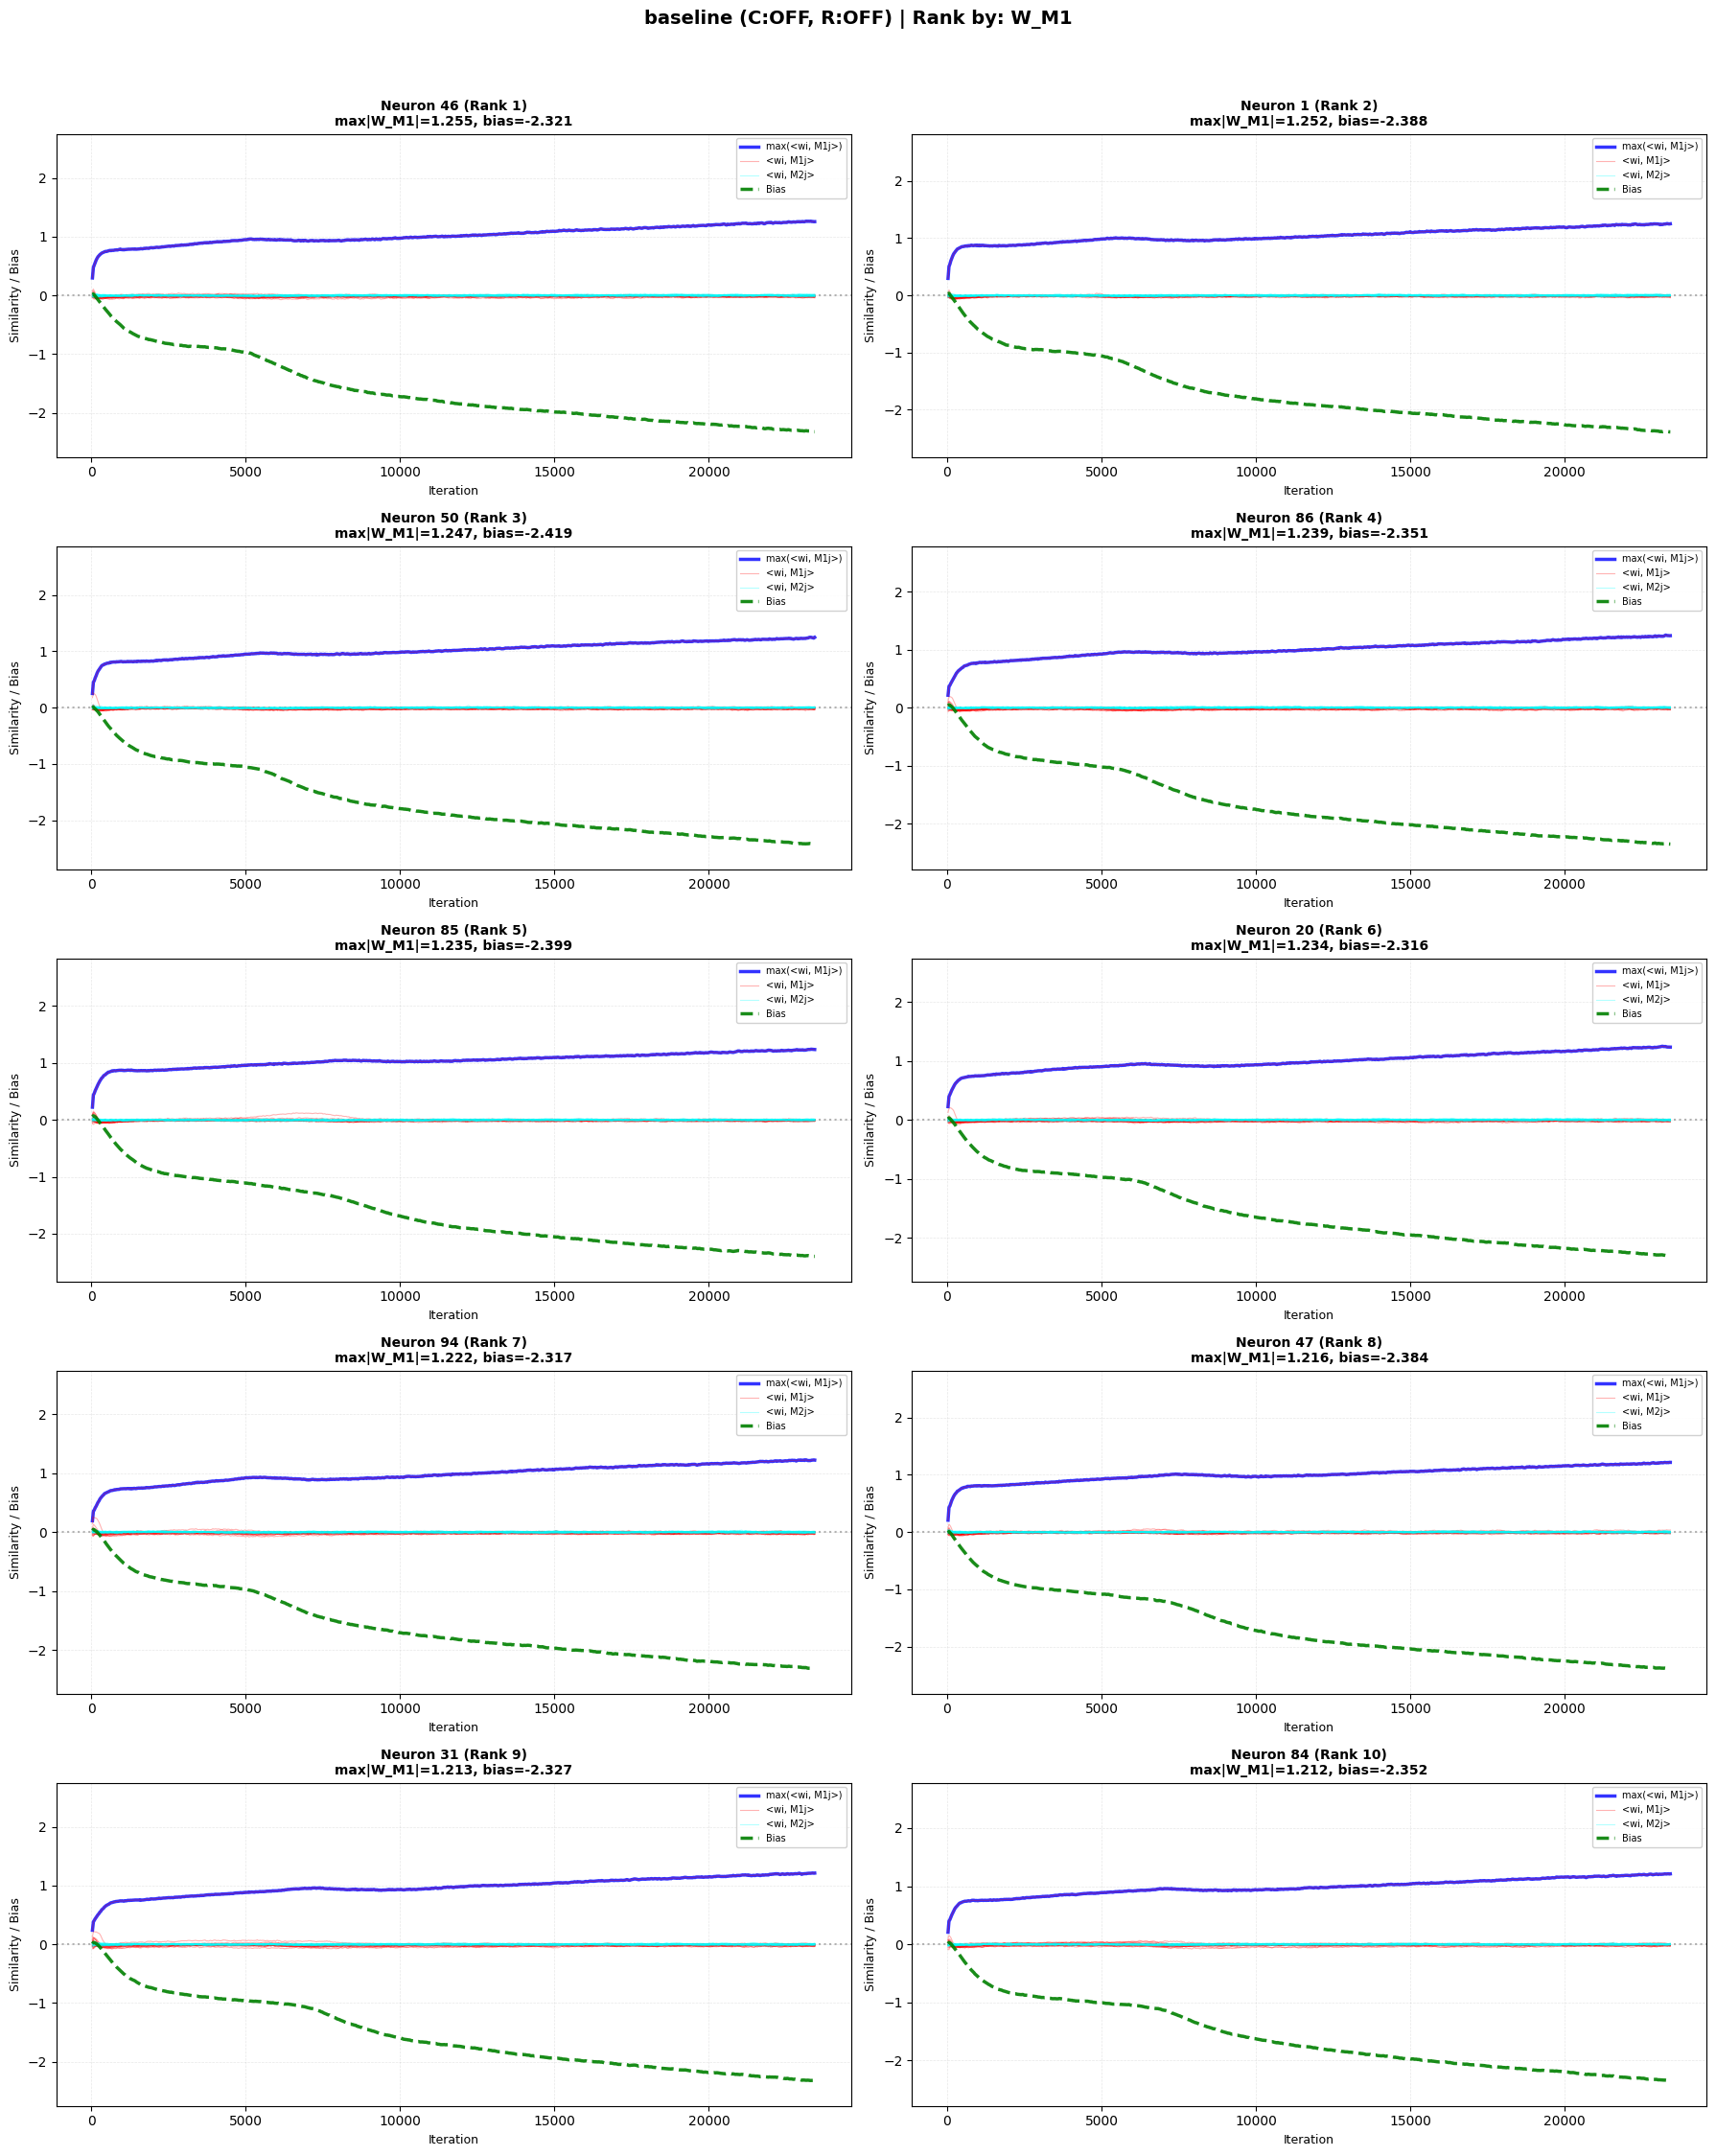

In [68]:
# baseline | W_M1 + W_M2
if 'baseline' in all_data_w_m1 and all_data_w_m1['baseline']:
    fig, _ = plot_comparison(all_data_w_m1['baseline'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='baseline (C:OFF, R:OFF)',
                              plot_tertiary=plot_tertiary)
    plt.show()

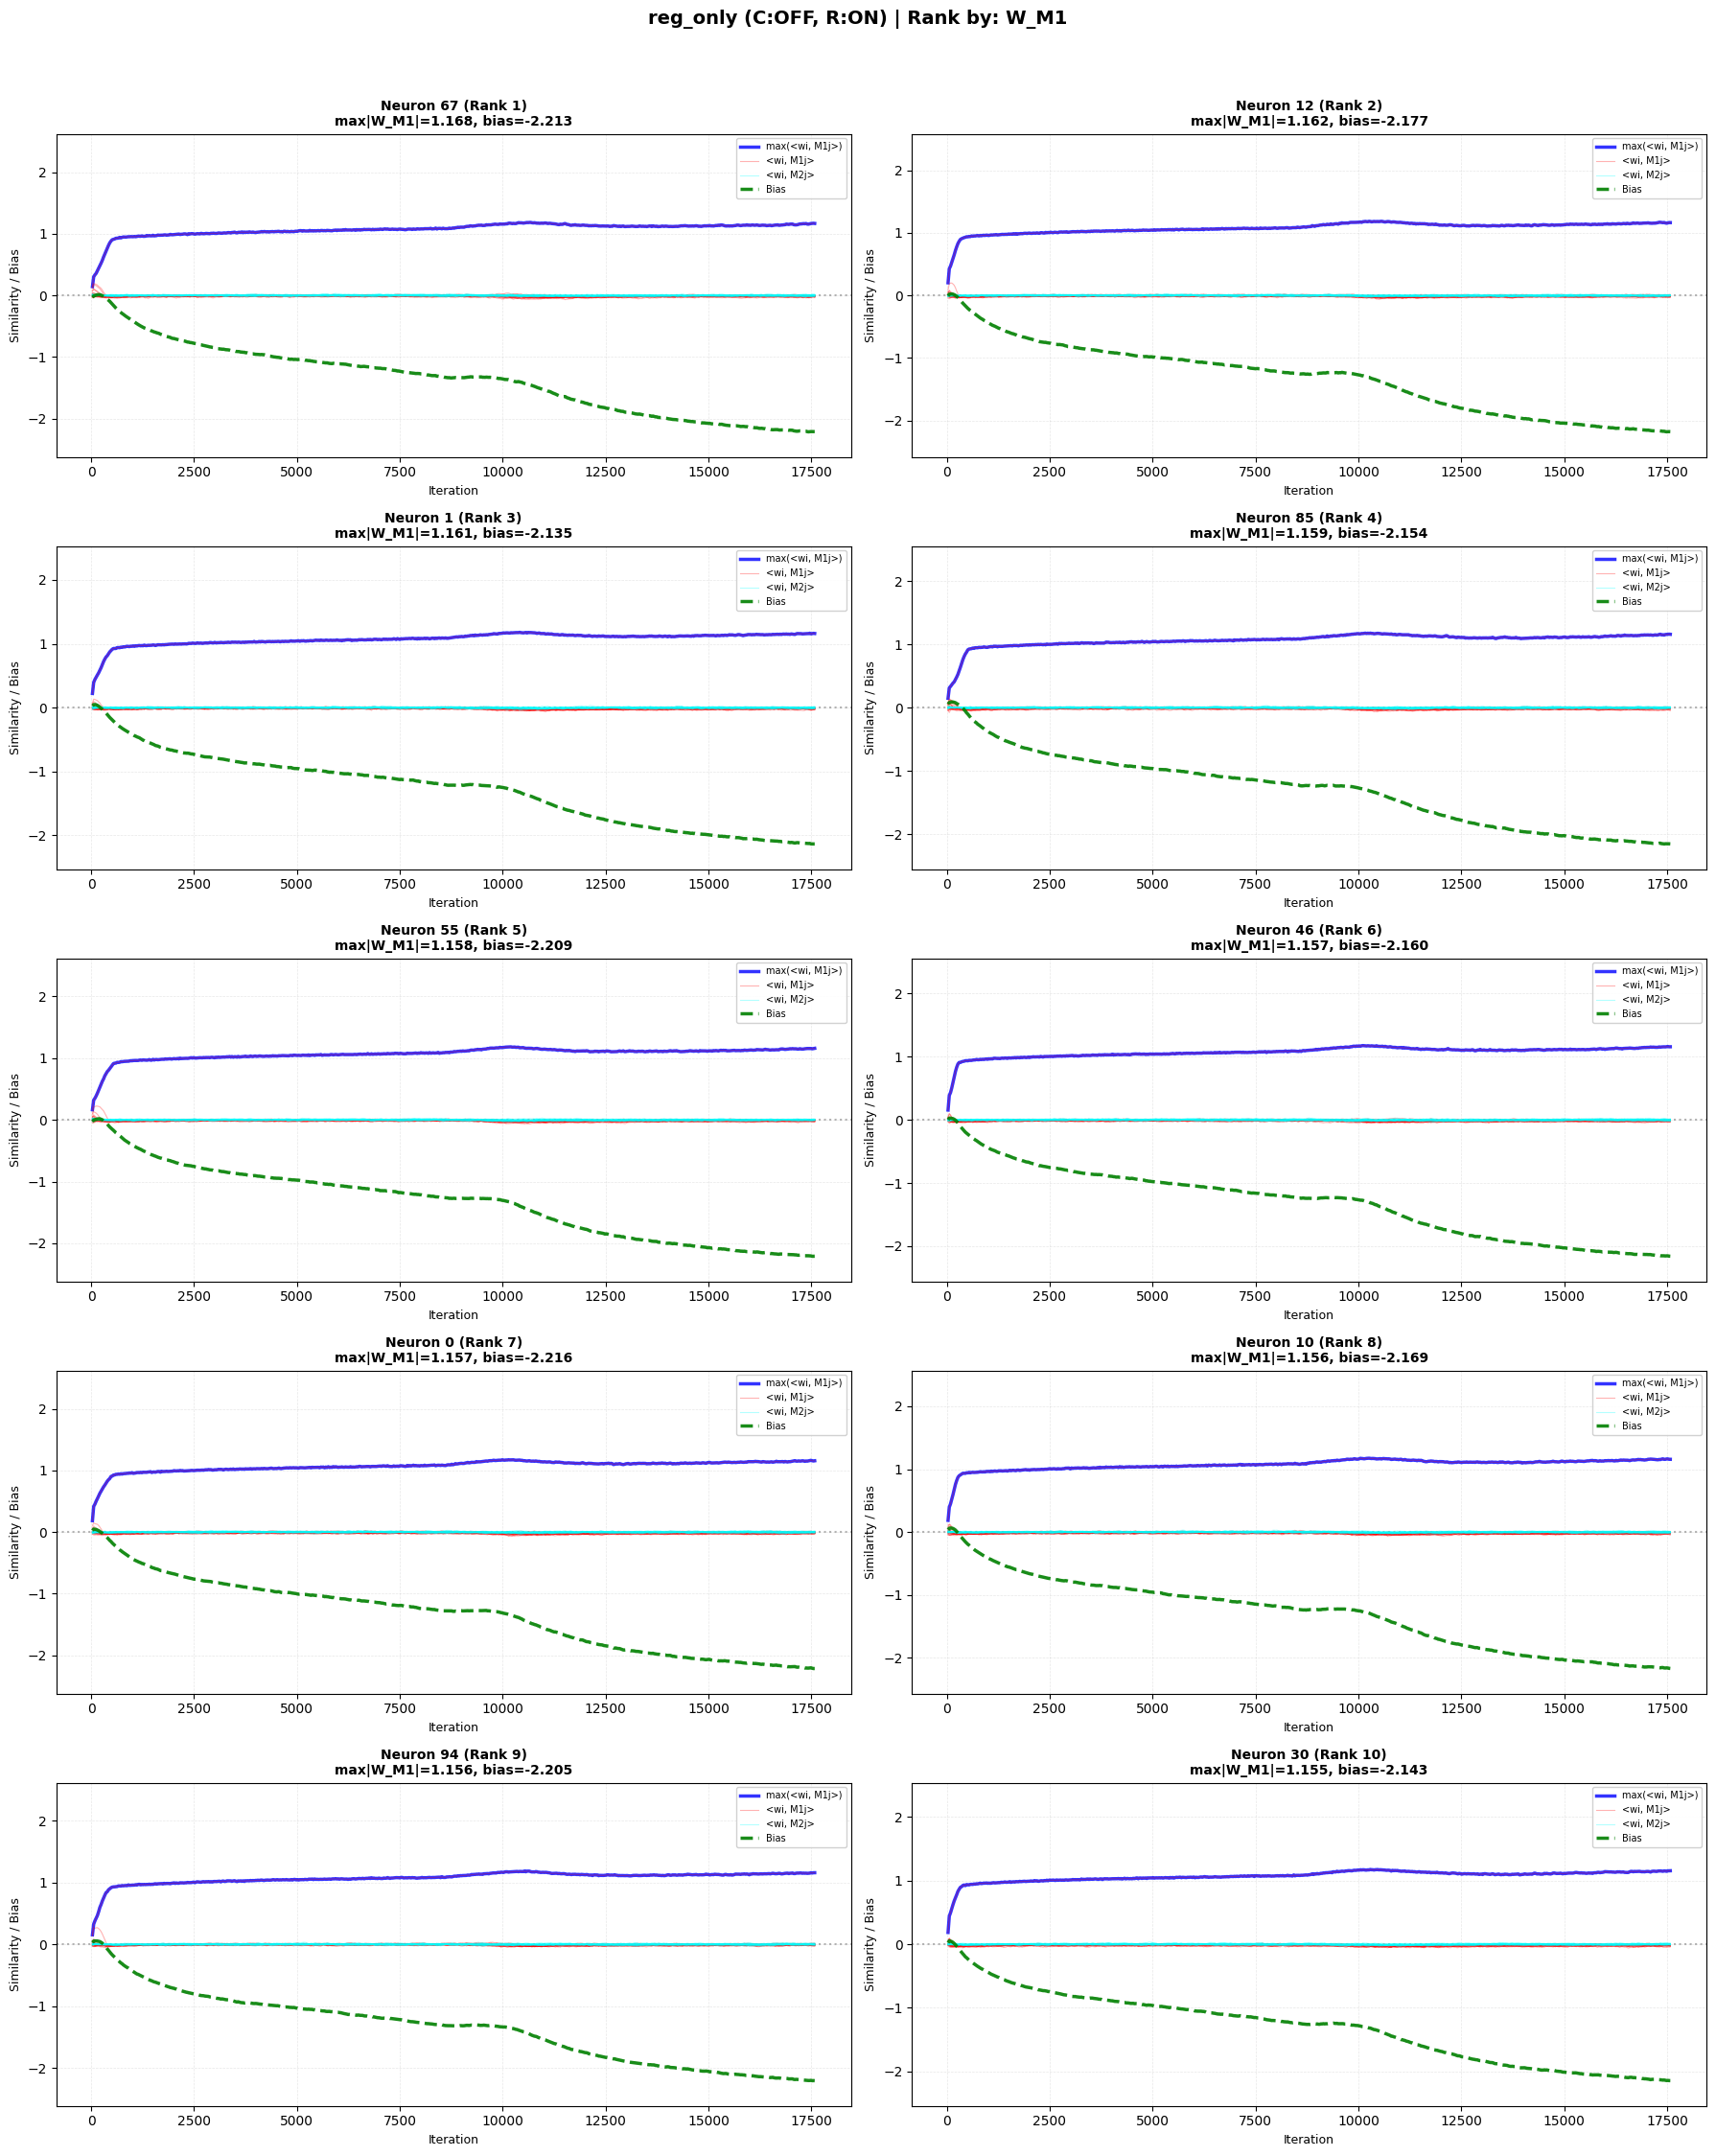

In [69]:
# reg_only | W_M1 + W_M2
if 'reg_only' in all_data_w_m1 and all_data_w_m1['reg_only']:
    fig, _ = plot_comparison(all_data_w_m1['reg_only'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='reg_only (C:OFF, R:ON)',
                              plot_tertiary=plot_tertiary)
    plt.show()

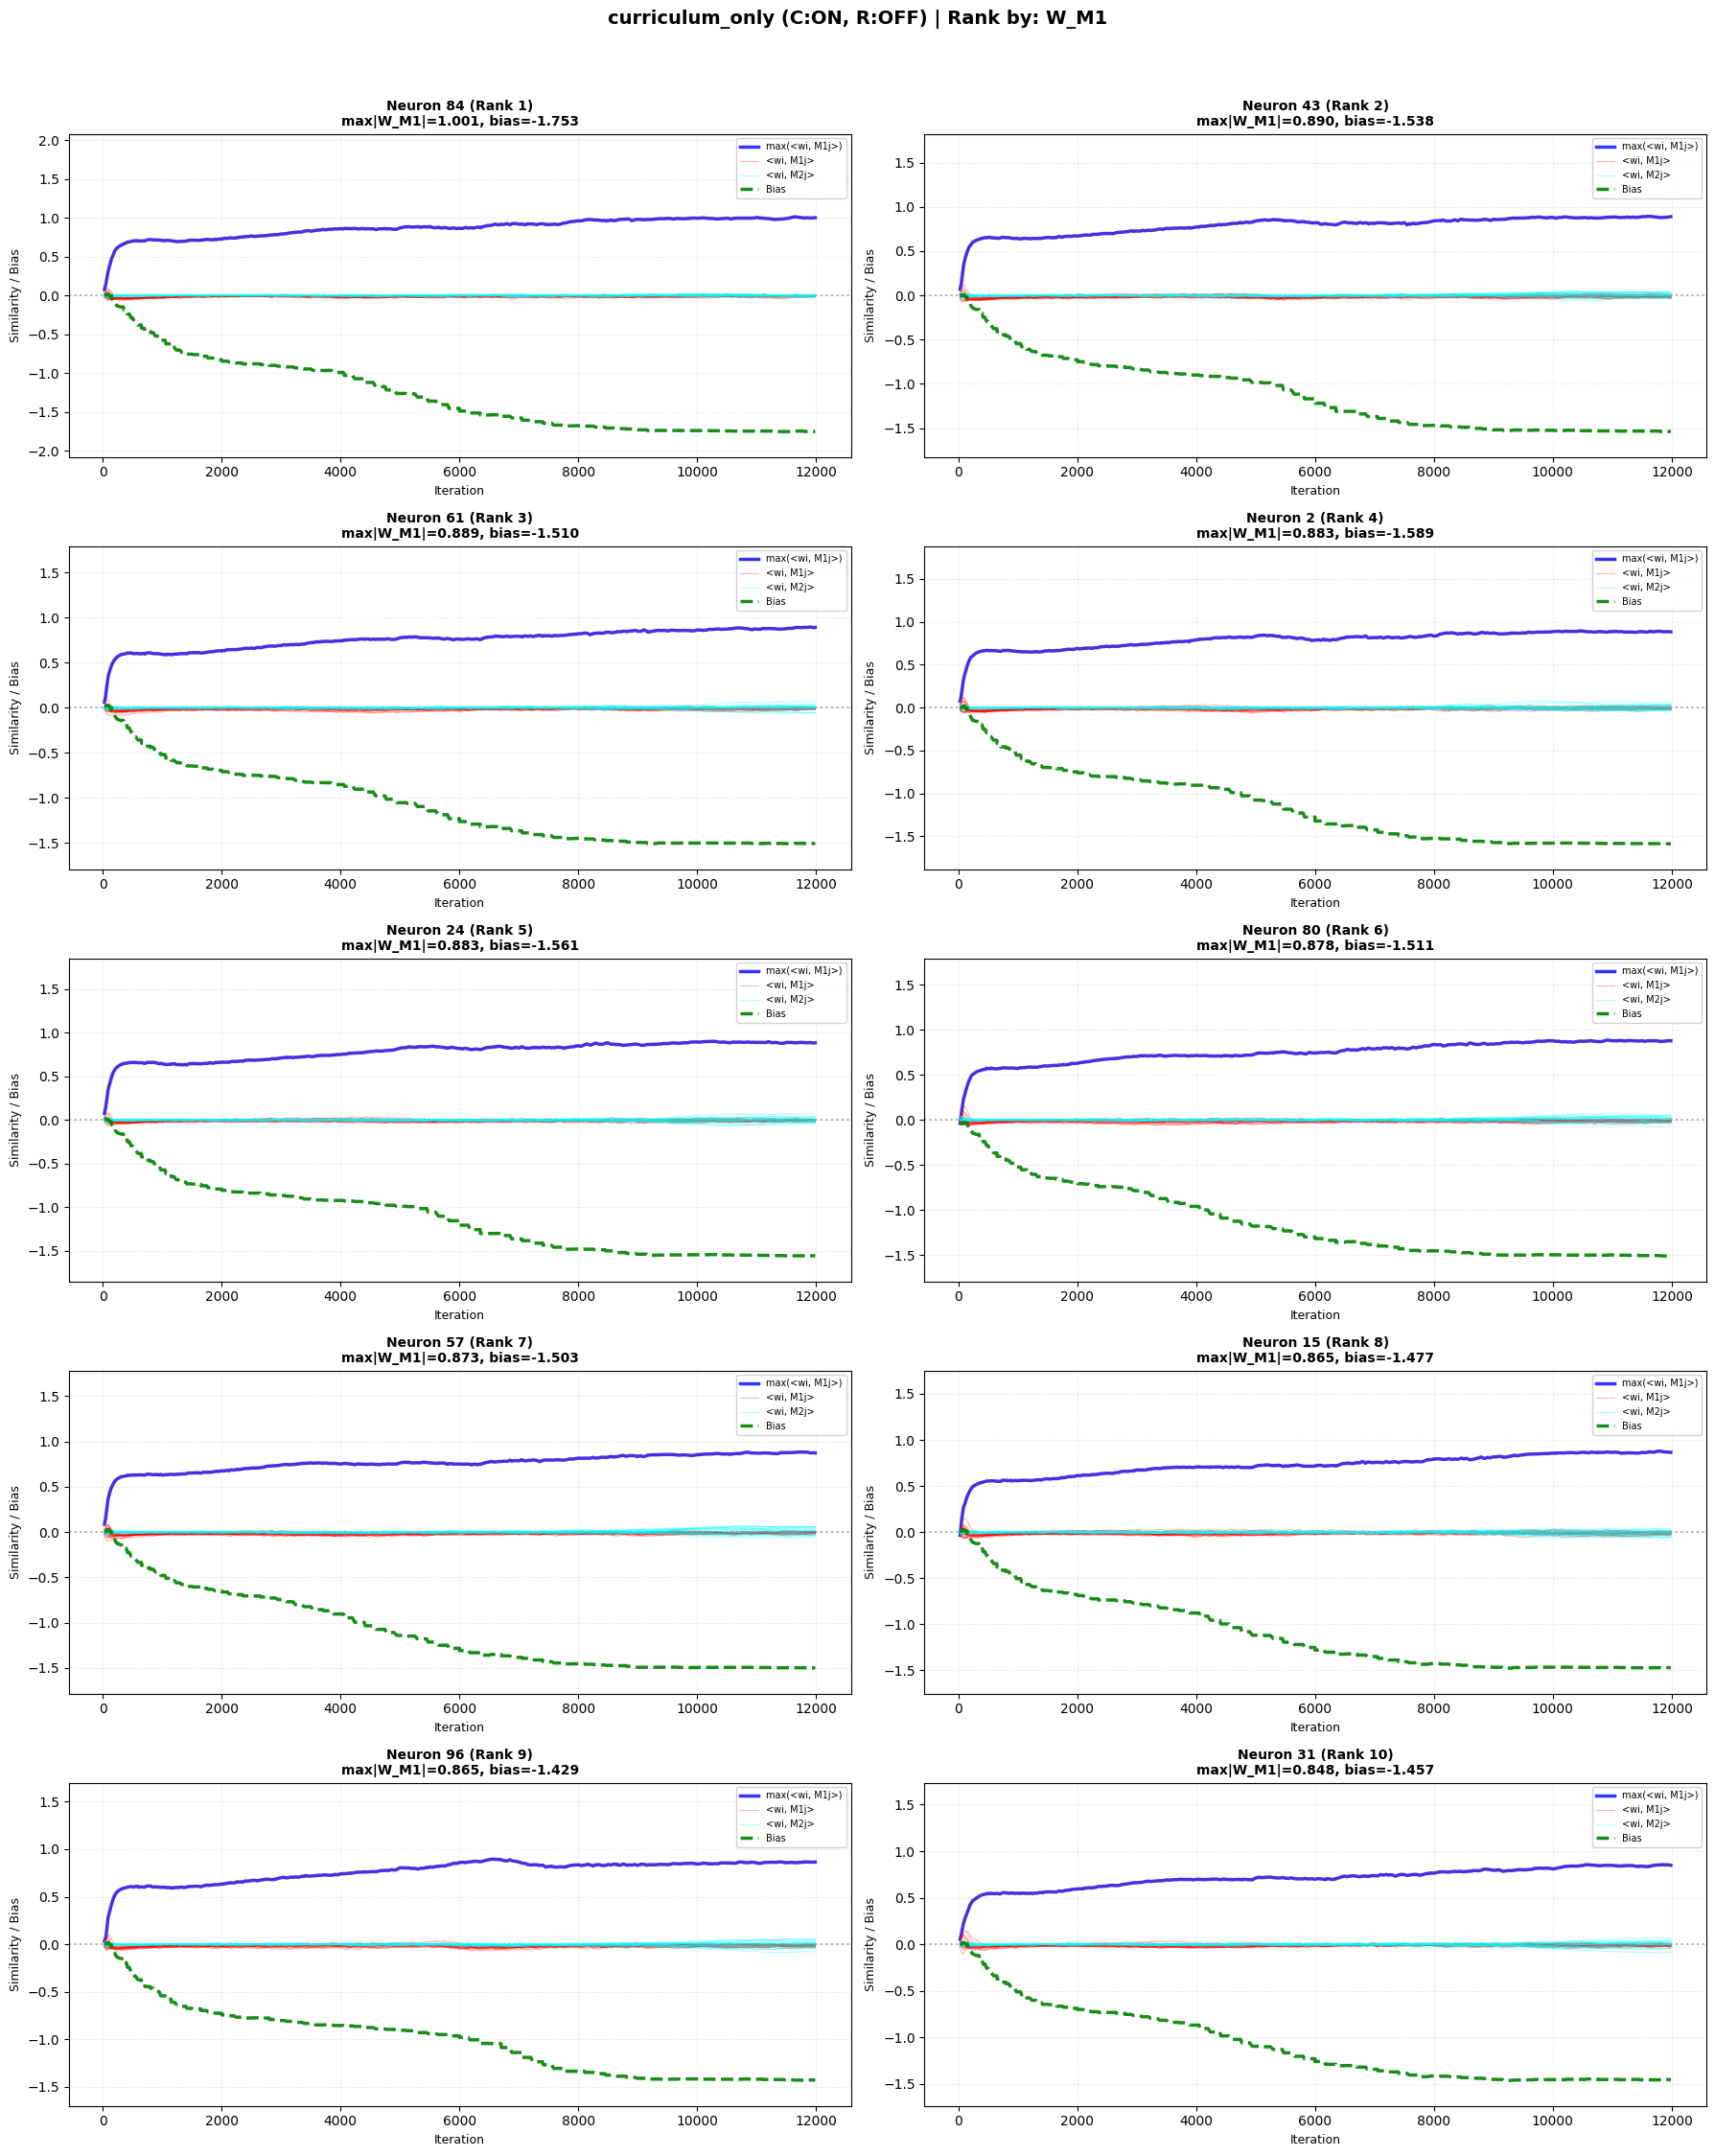

In [70]:
# curriculum_only | W_M1 + W_M2
if 'curriculum_only' in all_data_w_m1 and all_data_w_m1['curriculum_only']:
    fig, _ = plot_comparison(all_data_w_m1['curriculum_only'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='curriculum_only (C:ON, R:OFF)',
                              plot_tertiary=plot_tertiary)
    plt.show()


sparsity_only | Top 10 by max|W_M1|
Rank  1: Neuron  23 | sim=1.0265 (+) | bias=-1.1653
Rank  2: Neuron  28 | sim=1.0167 (+) | bias=-1.1689
Rank  3: Neuron  82 | sim=1.0133 (+) | bias=-1.1884
Rank  4: Neuron  93 | sim=1.0059 (+) | bias=-1.1746
Rank  5: Neuron   2 | sim=1.0052 (+) | bias=-1.1399
Rank  6: Neuron  48 | sim=0.9889 (+) | bias=-1.1242
Rank  7: Neuron  18 | sim=0.9862 (+) | bias=-1.1251
Rank  8: Neuron  13 | sim=0.9841 (+) | bias=-1.1793
Rank  9: Neuron  91 | sim=0.9827 (+) | bias=-1.1469
Rank 10: Neuron  24 | sim=0.9818 (+) | bias=-1.1490



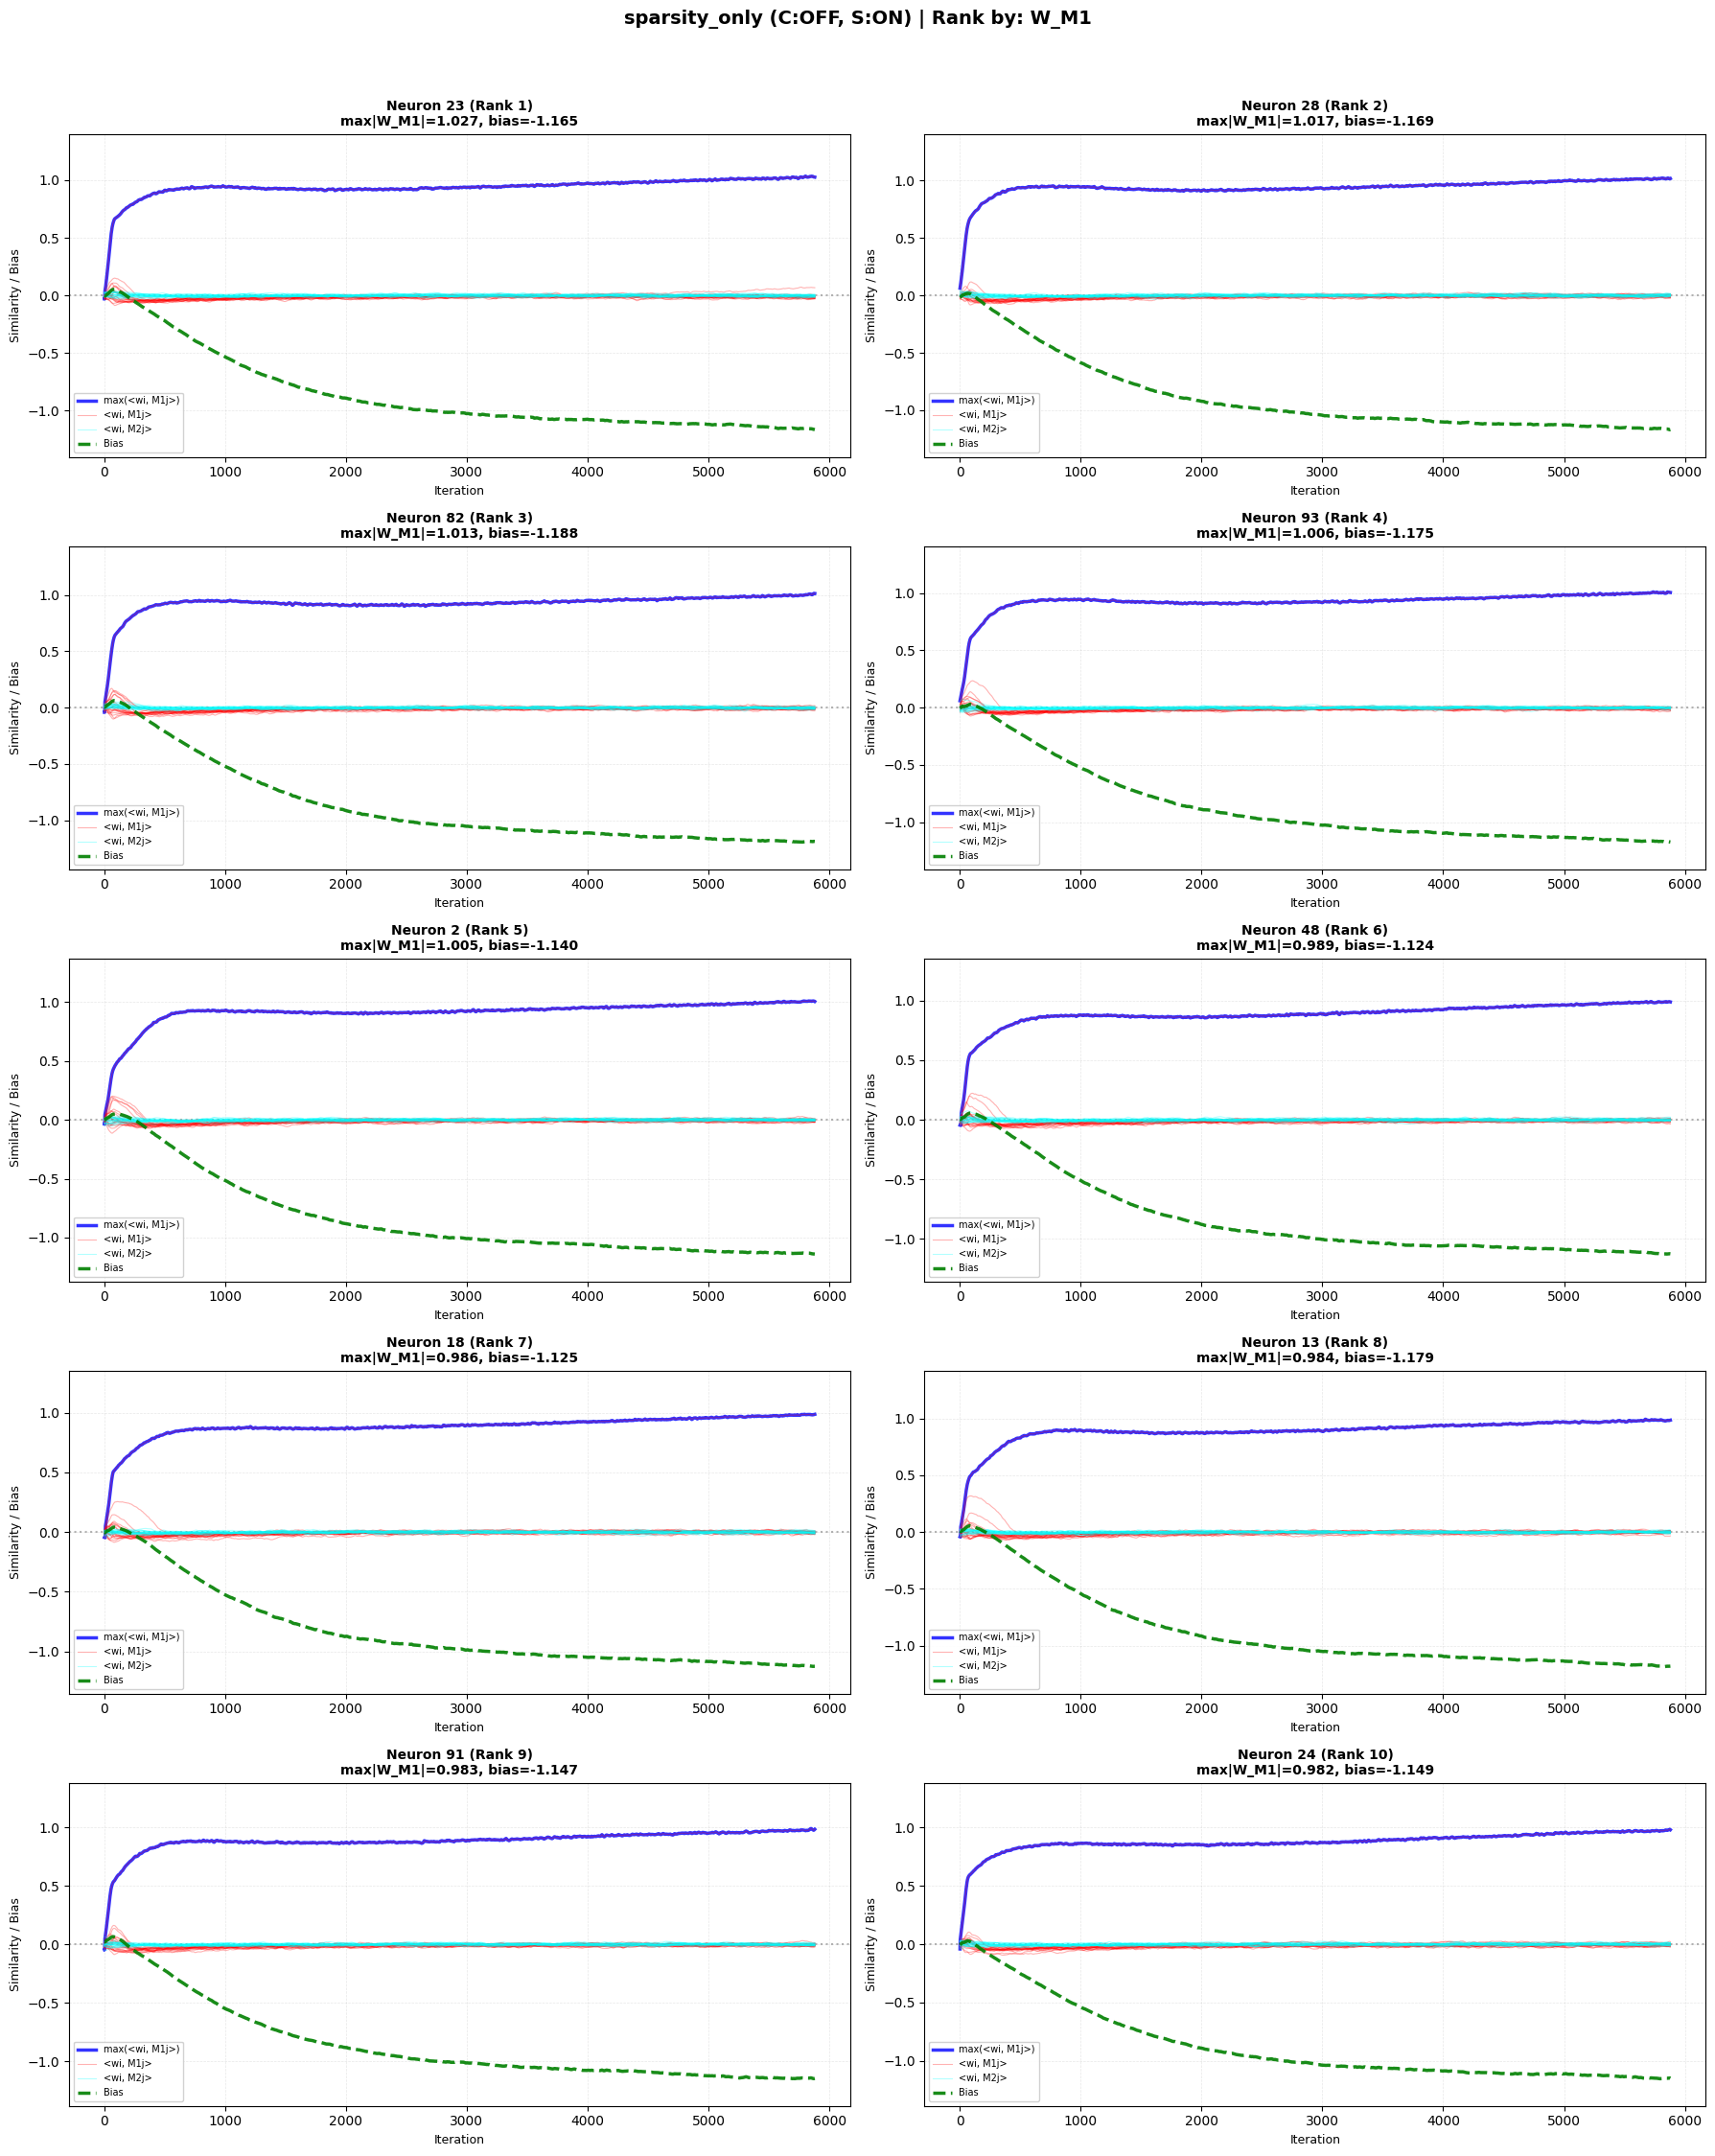

In [71]:
# sparsity_only | W_M1 + W_M2 (从旧项目加载数据)
if has_sparsity_comparison and 'sparsity_only' in old_results:
    rank_by = 'W_M1'
    plot_primary = 'W_M1'
    plot_secondary = 'W_M1'
    plot_tertiary = 'W_M2'
    
    sparsity_only_data_w_m1 = extract_top_neuron_data(old_results['sparsity_only'], rank_by, plot_primary, plot_secondary, show_bias, plot_tertiary)
    
    if sparsity_only_data_w_m1:
        print_ranking_table(sparsity_only_data_w_m1, rank_by, top_n, show_bias, 'sparsity_only')
        fig, _ = plot_comparison(sparsity_only_data_w_m1, rank_by, plot_primary, plot_secondary, 
                                  show_bias, top_n, figsize_single, title_prefix='sparsity_only (C:OFF, S:ON)',
                                  plot_tertiary=plot_tertiary)
        plt.show()


curriculum_sparsity | Top 10 by max|W_M1|
Rank  1: Neuron  95 | sim=1.0200 (+) | bias=-1.7724
Rank  2: Neuron  86 | sim=1.0122 (+) | bias=-1.7765
Rank  3: Neuron  62 | sim=0.9988 (+) | bias=-1.7573
Rank  4: Neuron  18 | sim=0.9968 (+) | bias=-1.7817
Rank  5: Neuron  71 | sim=0.9966 (+) | bias=-1.7520
Rank  6: Neuron  42 | sim=0.9668 (+) | bias=-1.6382
Rank  7: Neuron  84 | sim=0.9548 (+) | bias=-1.6570
Rank  8: Neuron  54 | sim=0.9396 (+) | bias=-1.6586
Rank  9: Neuron  89 | sim=0.9328 (+) | bias=-1.5883
Rank 10: Neuron  23 | sim=0.9239 (+) | bias=-1.5667



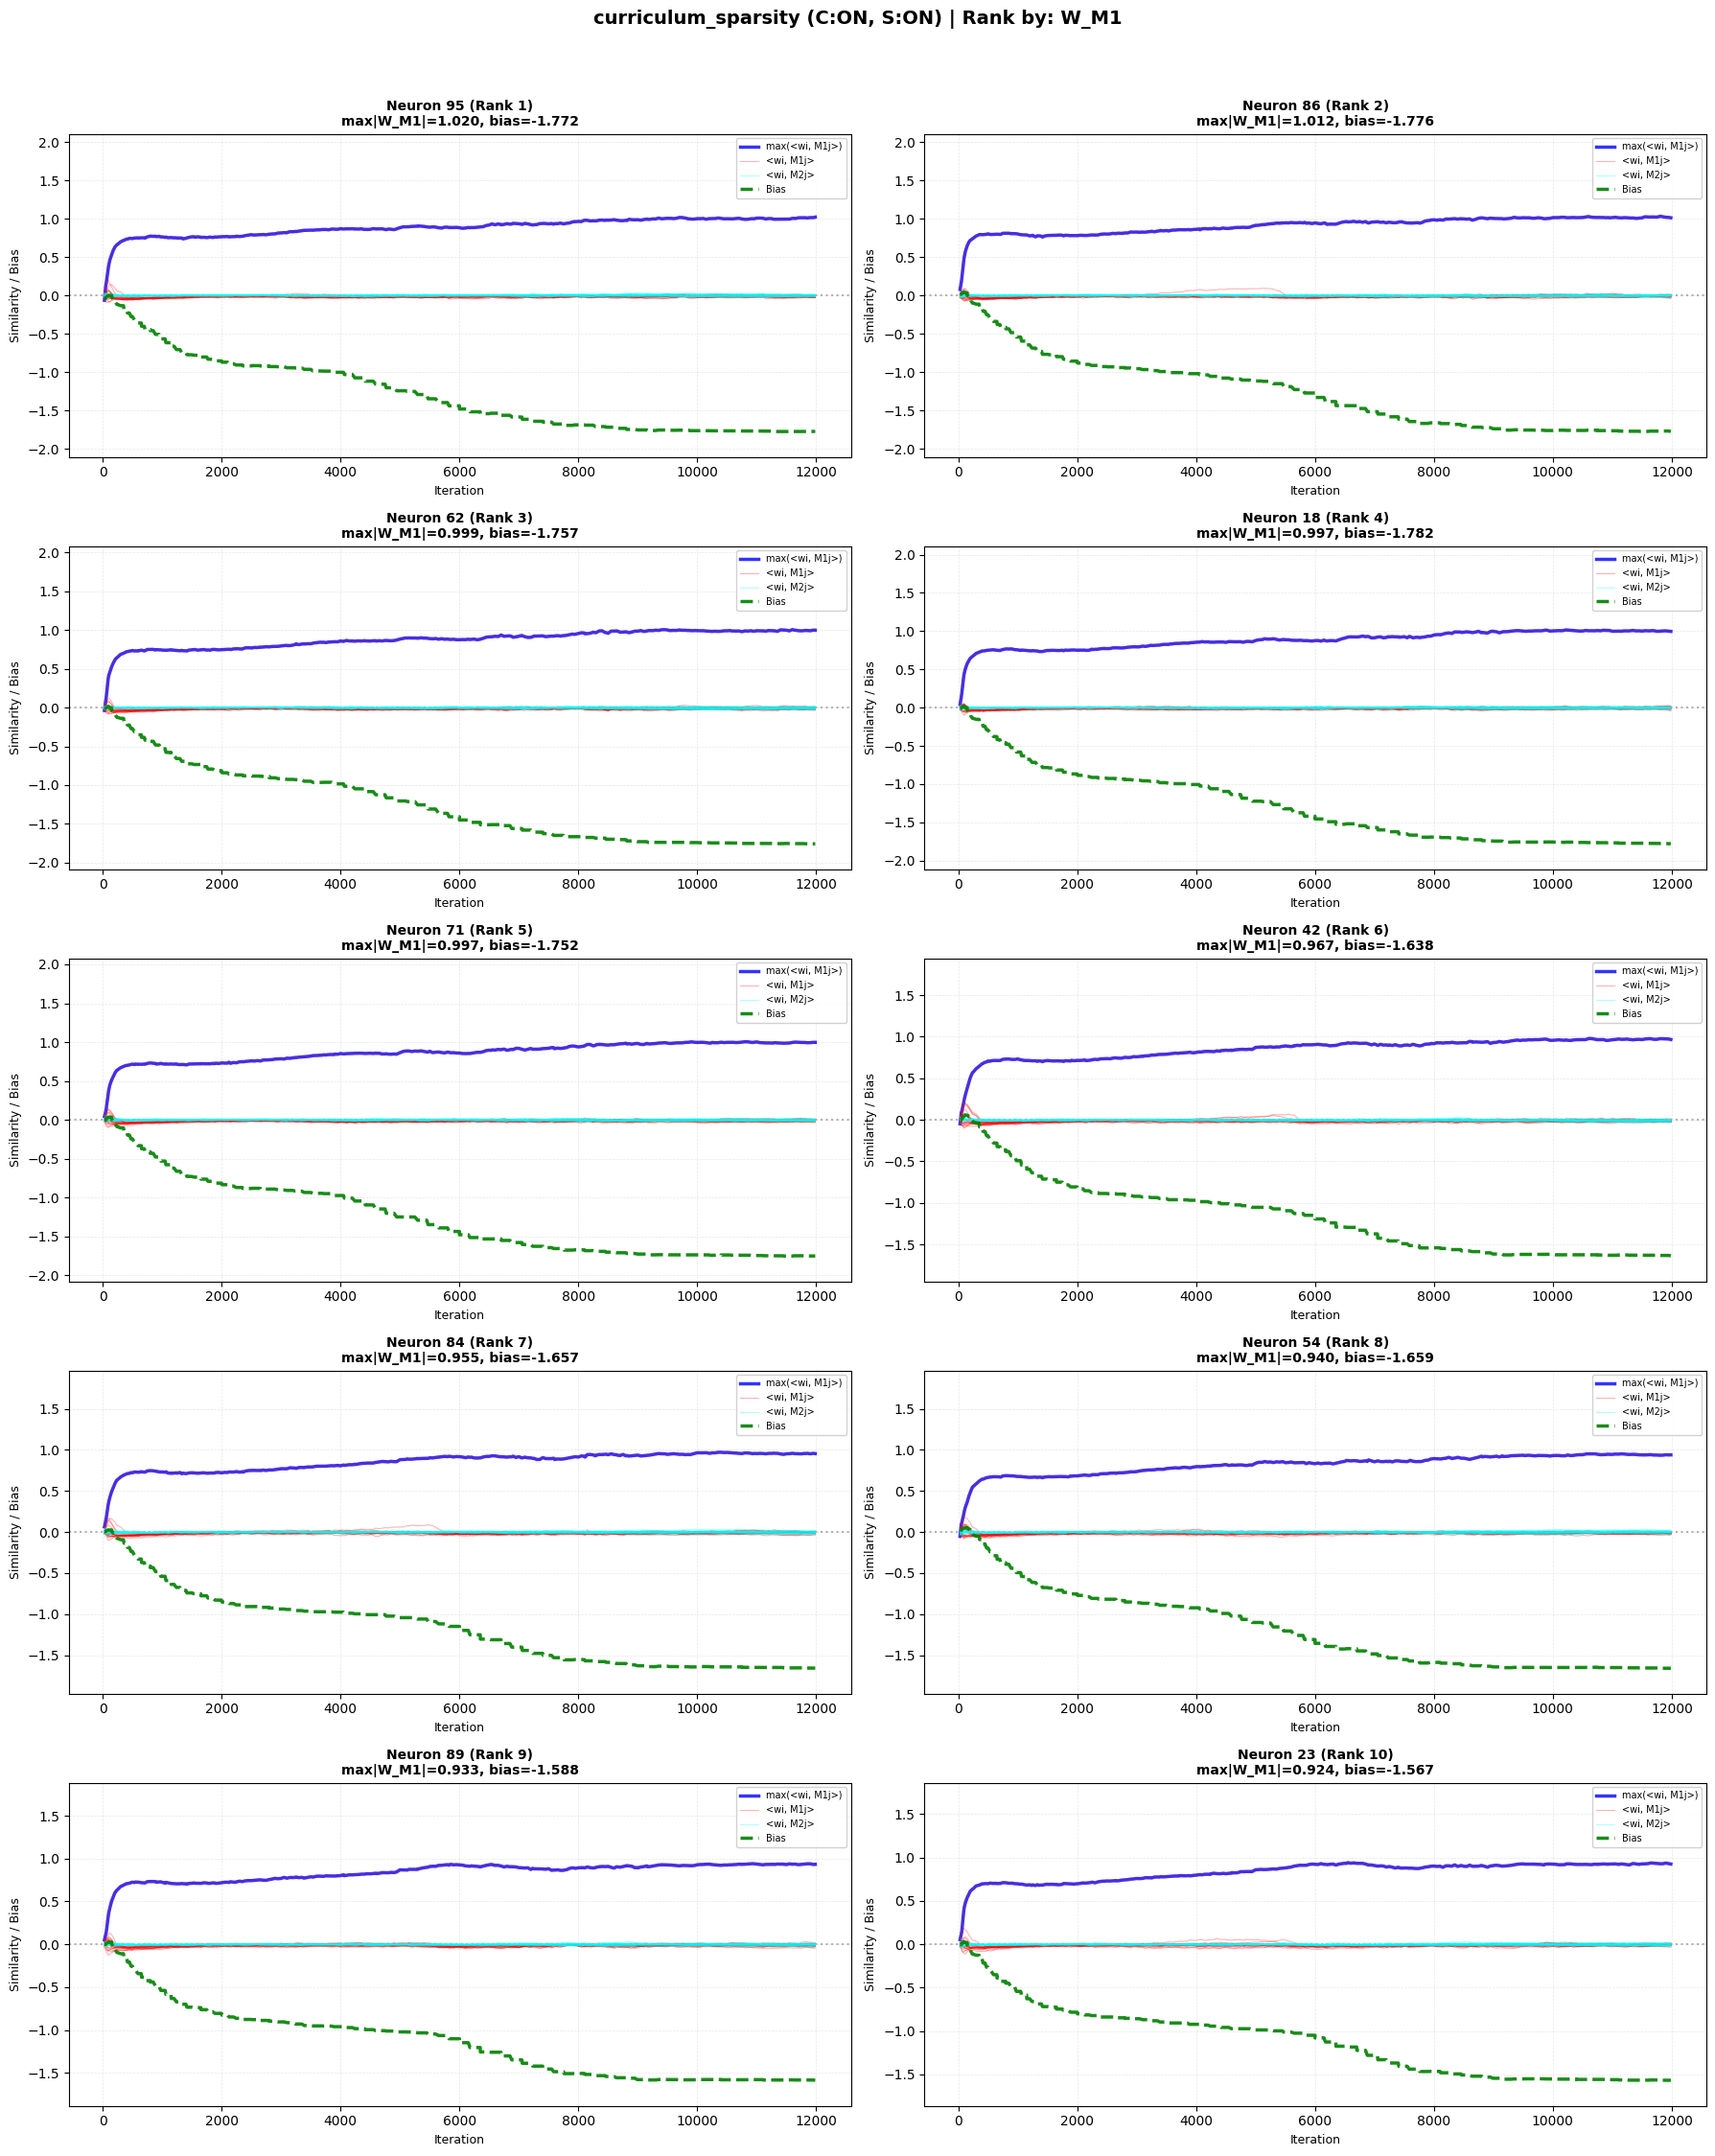

In [72]:
# curriculum_sparsity | W_M1 + W_M2 (从旧项目加载数据)
if has_sparsity_comparison and 'curriculum_sparsity' in old_results:
    rank_by = 'W_M1'
    plot_primary = 'W_M1'
    plot_secondary = 'W_M1'
    plot_tertiary = 'W_M2'
    
    curriculum_sparsity_data_w_m1 = extract_top_neuron_data(old_results['curriculum_sparsity'], rank_by, plot_primary, plot_secondary, show_bias, plot_tertiary)
    
    if curriculum_sparsity_data_w_m1:
        print_ranking_table(curriculum_sparsity_data_w_m1, rank_by, top_n, show_bias, 'curriculum_sparsity')
        fig, _ = plot_comparison(curriculum_sparsity_data_w_m1, rank_by, plot_primary, plot_secondary, 
                                  show_bias, top_n, figsize_single, title_prefix='curriculum_sparsity (C:ON, S:ON)',
                                  plot_tertiary=plot_tertiary)
        plt.show()

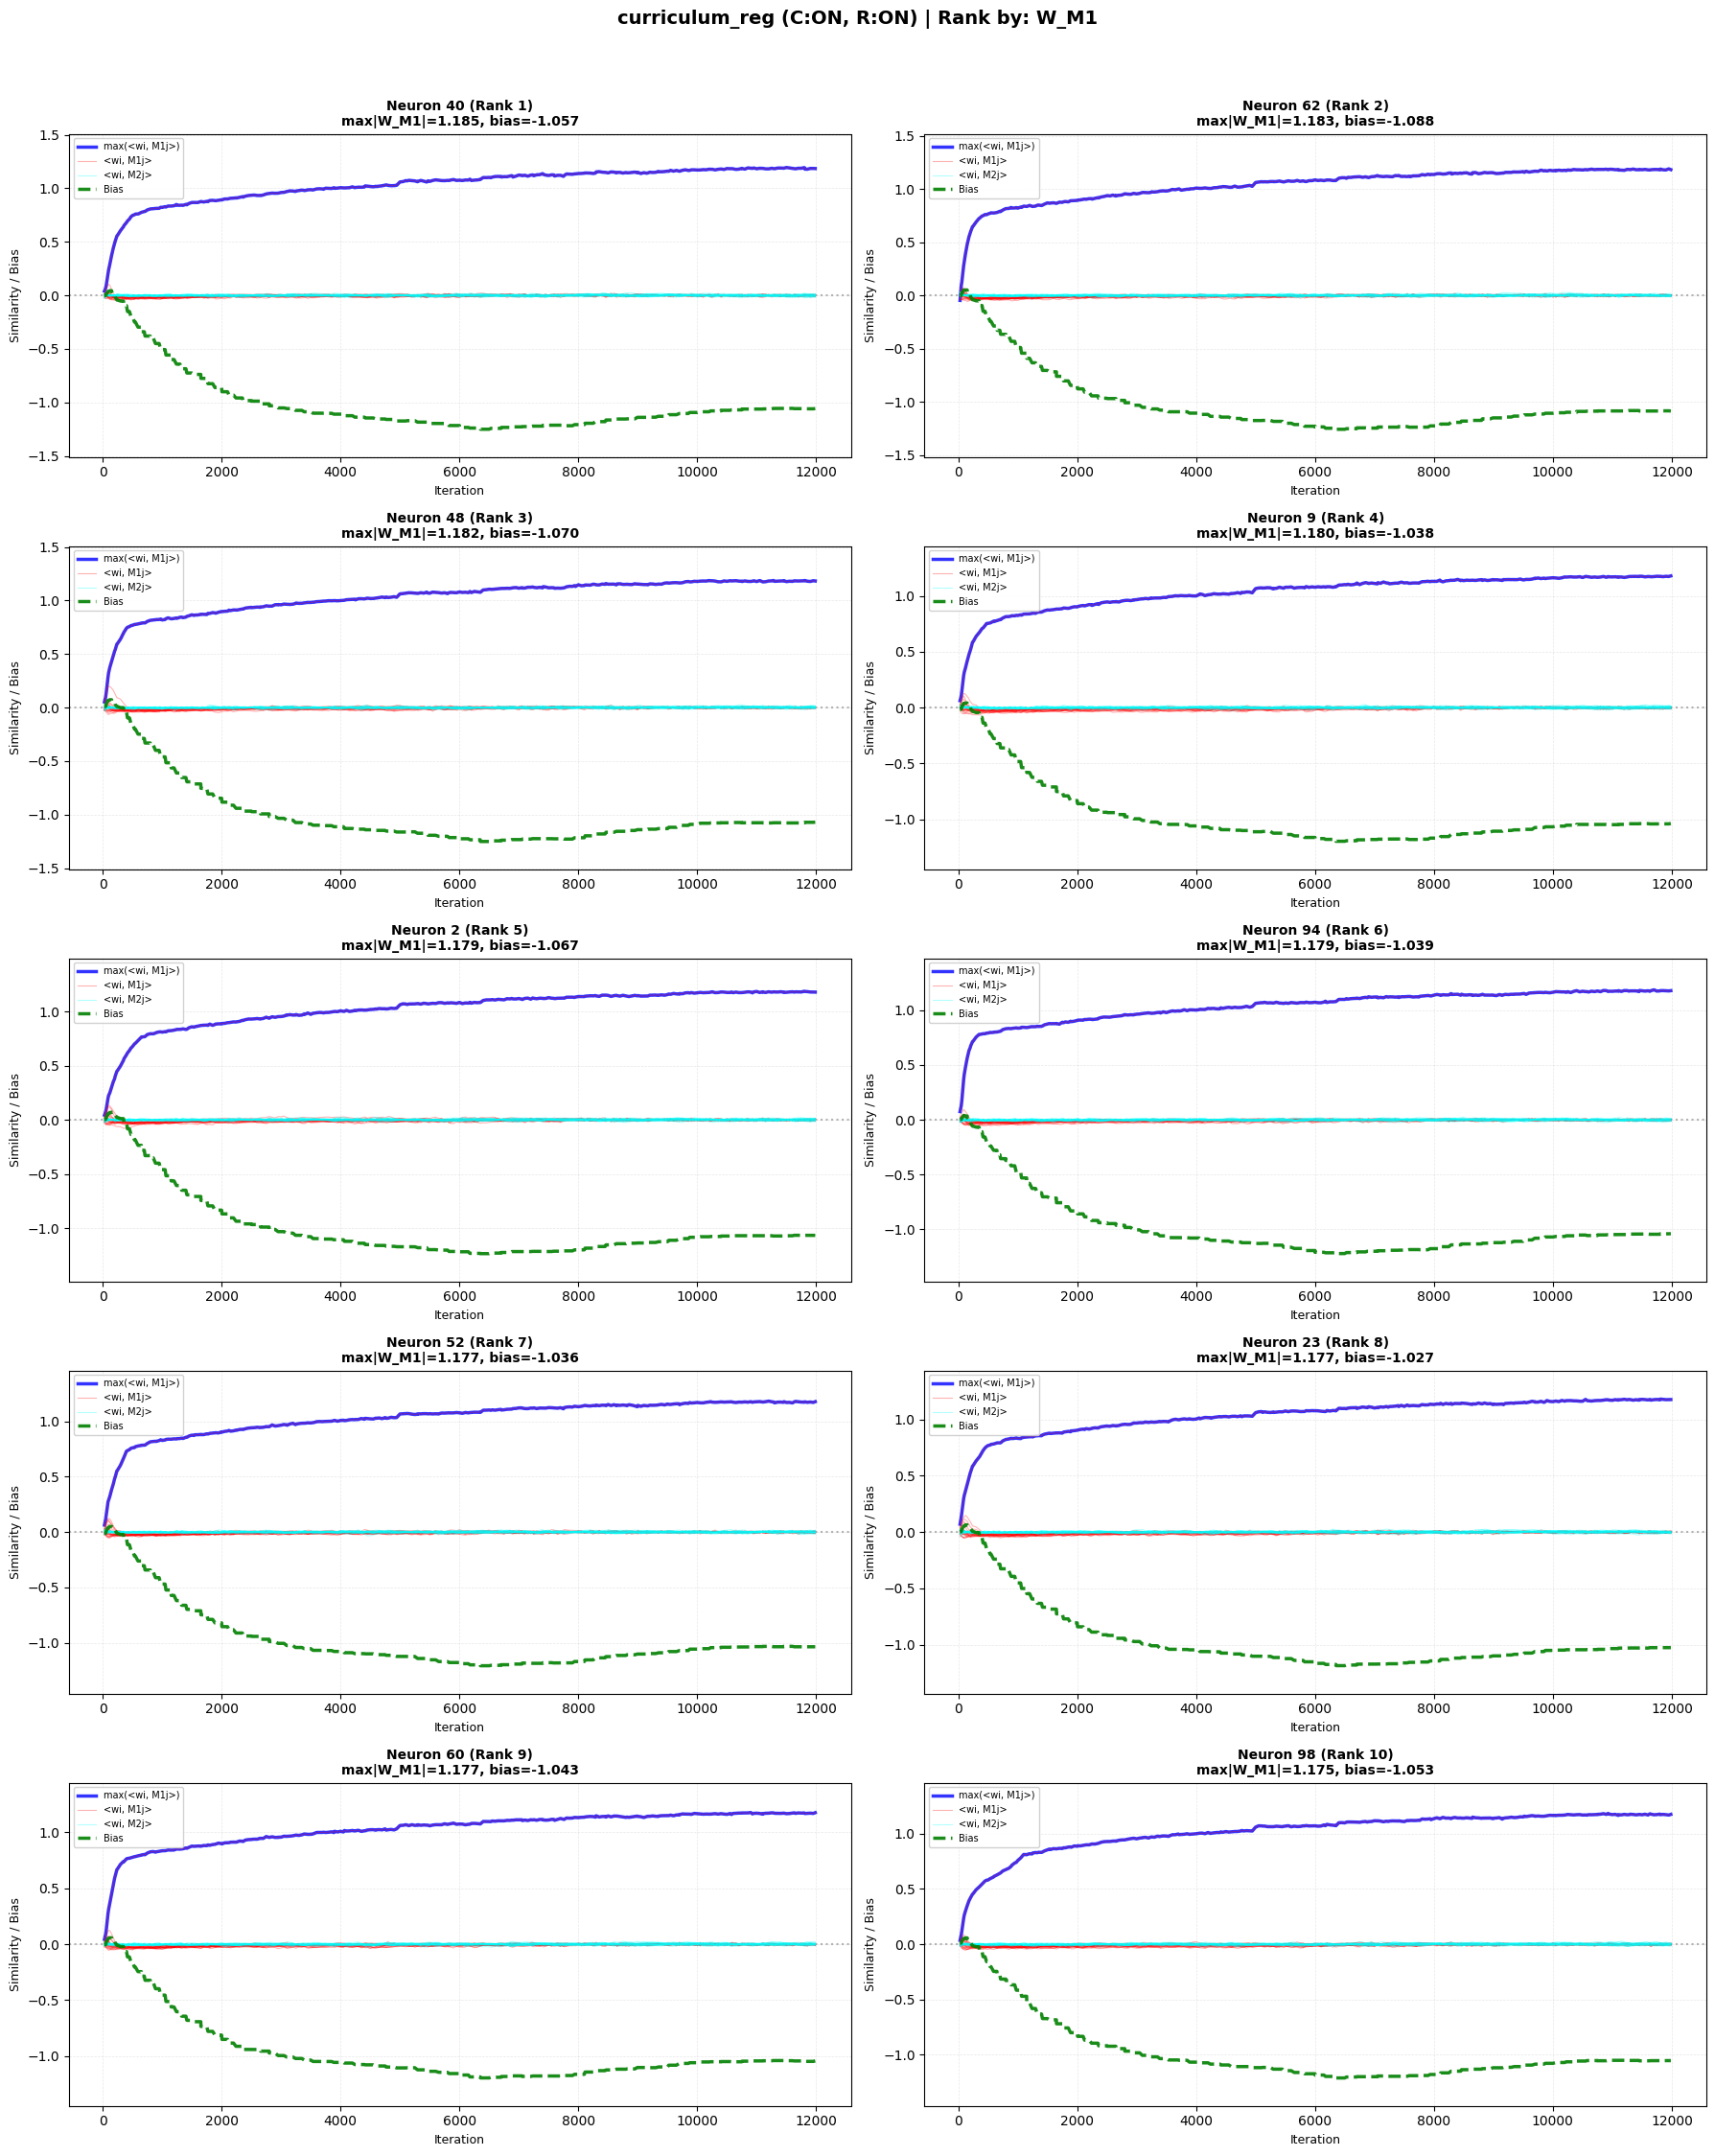

In [73]:
# curriculum_reg | W_M1 + W_M2
if 'curriculum_reg' in all_data_w_m1 and all_data_w_m1['curriculum_reg']:
    fig, _ = plot_comparison(all_data_w_m1['curriculum_reg'], rank_by, plot_primary, plot_secondary, 
                              show_bias, top_n, figsize_single, title_prefix='curriculum_reg (C:ON, R:ON)',
                              plot_tertiary=plot_tertiary)
    plt.show()

---
## Group L1 Regularization 特有分析

In [74]:
# 分析 reg_only 和 curriculum_reg 的稀疏性
print("\n" + "="*80)
print("GROUP L1 REGULARIZATION ANALYSIS")
print("="*80)

for name in ['reg_only', 'curriculum_reg']:
    if name not in all_results:
        print(f"\n{name}: Not loaded")
        continue
        
    result = all_results[name][0]
    
    # 检查是否有 sparsity_history
    sparsity_history = result.get('training_history', {}).get('sparsity_history', [])
    lambda_history = result.get('training_history', {}).get('lambda_history', [])
    
    print(f"\n{name}:")
    print(f"  is_reg: {result.get('is_reg', False)}")
    
    if lambda_history:
        lambda_vals = [f"{h['lambda']:.4f}" for h in lambda_history]
        print(f"  Lambda schedule: {lambda_vals}")
    
    if sparsity_history:
        final_sparsity = sparsity_history[-1]
        print(f"  Final active neurons: {final_sparsity.get('active_neurons', '?')}/{final_sparsity.get('total_neurons', '?')}")
        print(f"  Final sparsity: {final_sparsity.get('sparsity', 0):.1%}")
    else:
        print(f"  No sparsity history found")

print("\n" + "="*80)


GROUP L1 REGULARIZATION ANALYSIS

reg_only:
  is_reg: True
  No sparsity history found

curriculum_reg:
  is_reg: True
  Lambda schedule: ['0.0010', '0.0009', '0.0008', '0.0007', '0.0006', '0.0004', '0.0003', '0.0002', '0.0001', '0.0000']
  Final active neurons: 80/100
  Final sparsity: 20.0%



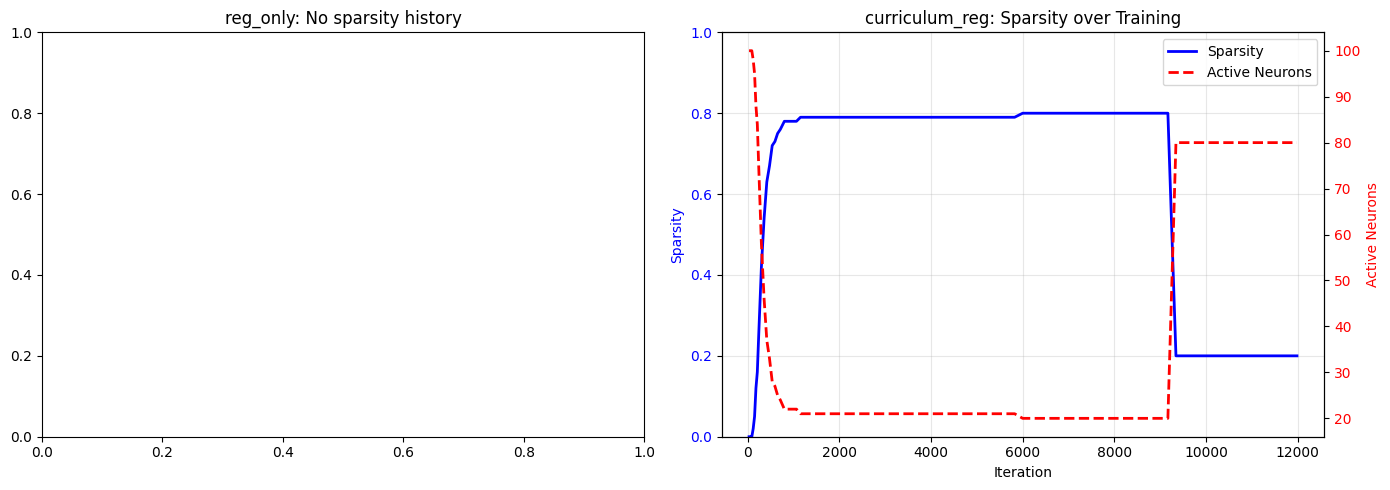

In [75]:
# 绘制稀疏度随训练变化曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, name in enumerate(['reg_only', 'curriculum_reg']):
    ax = axes[idx]
    
    if name not in all_results:
        ax.set_title(f'{name}: Not loaded')
        continue
    
    result = all_results[name][0]
    sparsity_history = result.get('training_history', {}).get('sparsity_history', [])
    
    if not sparsity_history:
        ax.set_title(f'{name}: No sparsity history')
        continue
    
    iterations = [h.get('iteration', i) for i, h in enumerate(sparsity_history)]
    sparsities = [h.get('sparsity', 0) for h in sparsity_history]
    active_neurons = [h.get('active_neurons', 0) for h in sparsity_history]
    
    ax.plot(iterations, sparsities, 'b-', linewidth=2, label='Sparsity')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Sparsity', color='blue')
    ax.tick_params(axis='y', labelcolor='blue')
    ax.set_ylim(0, 1)
    
    ax2 = ax.twinx()
    ax2.plot(iterations, active_neurons, 'r--', linewidth=2, label='Active Neurons')
    ax2.set_ylabel('Active Neurons', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    ax.set_title(f'{name}: Sparsity over Training')
    ax.grid(True, alpha=0.3)
    
    # 合并图例
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

NameError: name 'sparsity_data' is not defined

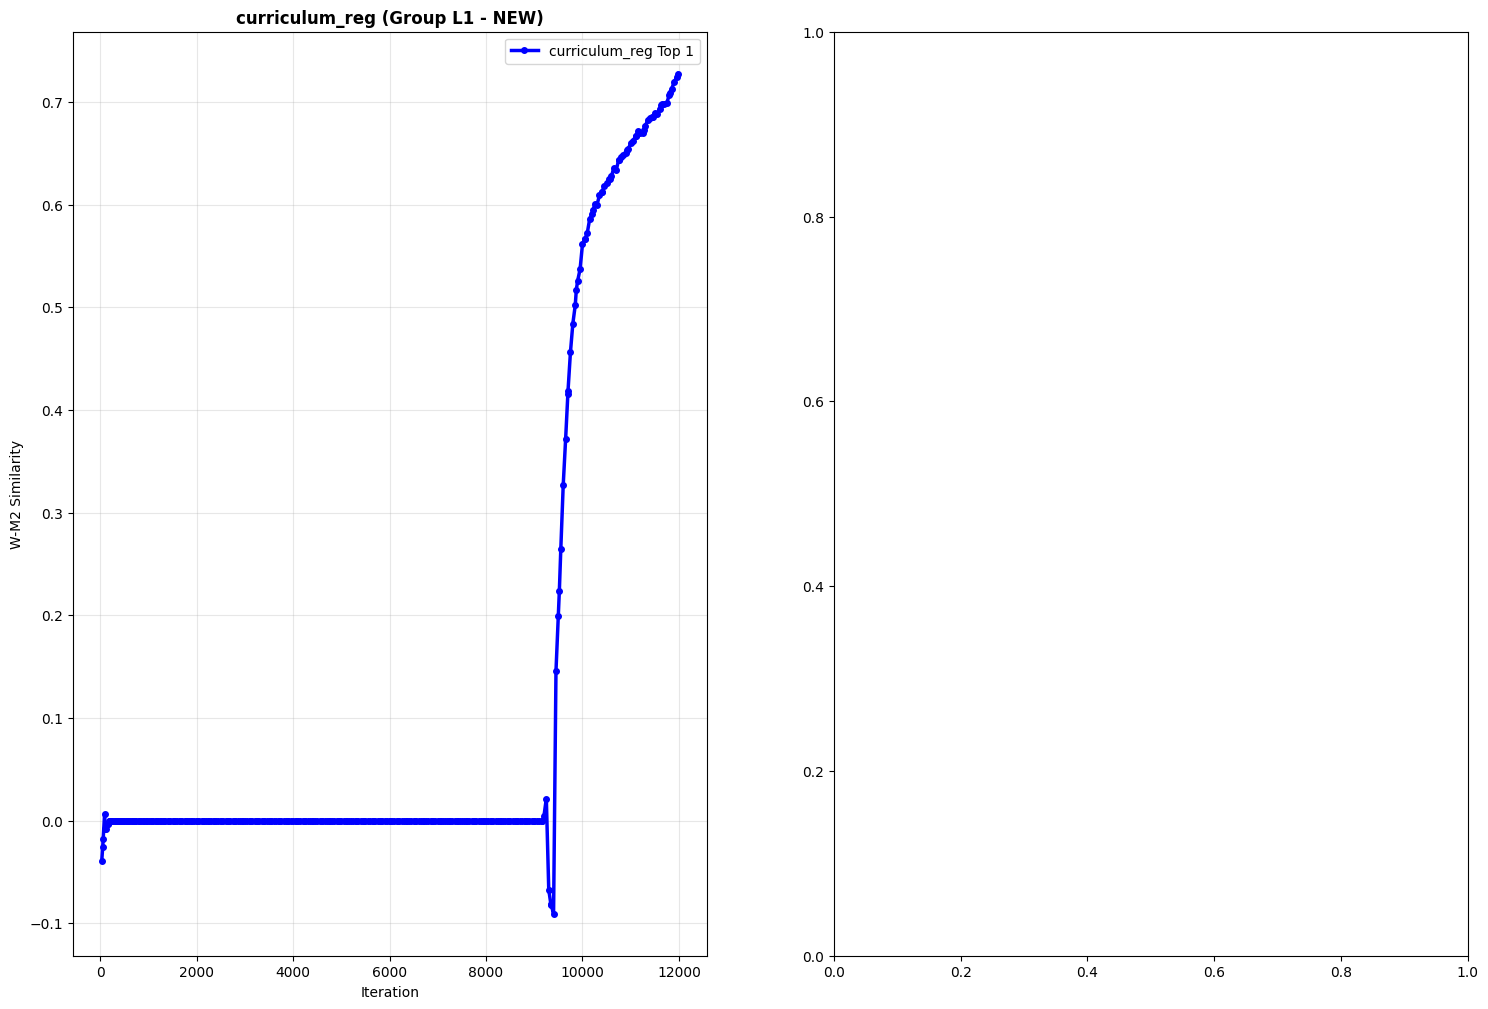

In [76]:
# 绘制对比图：curriculum_reg vs curriculum_sparsity (W_M2)
if has_sparsity_comparison and 'curriculum_reg' in all_data_w_m2 and all_data_w_m2['curriculum_reg']:
    fig, axes = plt.subplots(1, 2, figsize=(18, 12))
    
    # 左图：curriculum_reg (Group L1)
    rank_by = 'W_M2'
    plot_primary = 'W_M2'
    plot_secondary = 'W_M2'
    plot_tertiary = 'W_M1'
    
    reg_data = all_data_w_m2['curriculum_reg']
    iterations = reg_data['iterations']
    biases = reg_data['biases']
    sims_primary = reg_data['sims_primary']
    sims_secondary = reg_data['sims_secondary']
    sims_tertiary = reg_data.get('sims_tertiary', {})
    sorted_neurons = reg_data['sorted_neurons']
    
    # 选择 Top 3 进行对比展示
    for plot_idx in range(3):
        if plot_idx < len(sorted_neurons):
            neuron_idx, final_abs_sim = sorted_neurons[plot_idx]
            ax = axes[0] if plot_idx == 0 else None
            
            if plot_idx == 0:
                # 使用第一个子图展示 curriculum_reg 的 Top 神经元
                max_sims = [sims_primary[neuron_idx][t][np.argmax(np.abs(sims_primary[neuron_idx][t]))] 
                           for t in range(len(iterations))]
                
                ax.plot(iterations, max_sims, 'b-', linewidth=2.5, label=f'curriculum_reg Top {plot_idx+1}', marker='o', markersize=4)
                ax.set_title('curriculum_reg (Group L1 - NEW)', fontsize=12, fontweight='bold')
                ax.set_xlabel('Iteration')
                ax.set_ylabel('W-M2 Similarity')
                ax.grid(True, alpha=0.3)
                ax.legend(fontsize=10)
    
    # 右图：curriculum_sparsity (Hard-Mask)
    if sparsity_data:
        iterations_s = sparsity_data['iterations']
        sims_primary_s = sparsity_data['sims_primary']
        sorted_neurons_s = sparsity_data['sorted_neurons']
        
        for plot_idx in range(3):
            if plot_idx < len(sorted_neurons_s):
                neuron_idx, final_abs_sim = sorted_neurons_s[plot_idx]
                
                if plot_idx == 0:
                    max_sims = [sims_primary_s[neuron_idx][t][np.argmax(np.abs(sims_primary_s[neuron_idx][t]))] 
                               for t in range(len(iterations_s))]
                    
                    axes[1].plot(iterations_s, max_sims, 'r-', linewidth=2.5, label=f'curriculum_sparsity Top {plot_idx+1}', marker='s', markersize=4)
        
        axes[1].set_title('curriculum_sparsity (Hard-Mask - OLD)', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('W-M2 Similarity')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# 对比分析：curriculum_reg vs curriculum_sparsity
if has_sparsity_comparison:
    print("\n" + "="*80)
    print("DETAILED COMPARISON: curriculum_reg (Group L1) vs curriculum_sparsity (Hard-Mask)")
    print("="*80)
    
    rank_by = 'W_M2'
    plot_primary = 'W_M2'
    plot_secondary = 'W_M2'
    plot_tertiary = 'W_M1'
    
    # 提取两个数据集
    if 'curriculum_reg' in all_data_w_m2 and all_data_w_m2['curriculum_reg']:
        reg_data = all_data_w_m2['curriculum_reg']
    else:
        reg_data = None
    
    sparsity_data = extract_top_neuron_data(curriculum_sparsity_results, rank_by, plot_primary, plot_secondary, show_bias, plot_tertiary)
    
    print(f"\nTop 10 by max|{rank_by}|:")
    print("\n--- curriculum_reg (Group L1 - NEW) ---")
    if reg_data:
        print_ranking_table(reg_data, rank_by, 10, show_bias, "curriculum_reg")
    
    print("\n--- curriculum_sparsity (Hard-Mask - OLD) ---")
    if sparsity_data:
        print_ranking_table(sparsity_data, rank_by, 10, show_bias, "curriculum_sparsity")
    
    print("="*80)

: 

In [ ]:
---
## Cross-project Comparison: Group L1 Reg vs Hard-Mask Sparsity

: 

---
## Cross-project Comparison: Reg vs Sparsity

Compare the new Group L1 Regularization approach with the previous hard-mask Sparsity approach

: 

: 

: 

: 

: 